<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-Assignment-2/blob/main/SMAI_assign_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1**
Bike Rental Demand Prediction with Linear Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

from sklearn.model_selection import train_test_split

username = "manoj.pentakota"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

df = pd.read_csv("/content/hour.csv")

print("Dataset shapeL:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

display(df.tail())

print(df.dtypes)

Dataset shapeL: (17379, 17)

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [4]:
TARGET="cnt"

DROP_COLUMNS= ["cnt","casual","registered","instant","dteday"]

x_raw = df.drop(columns=DROP_COLUMNS)
y_raw = df[TARGET]

print(x_raw.shape)
print(x_raw.columns.tolist())

(17379, 12)
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [5]:
#one hot encoding
categorial_features = ["season",'mnth',"hr","holiday","weekday","weathersit"]
continuos_features = ["temp","atemp","hum","windspeed"]

x_base = x_raw.drop(columns=["workingday"])

x_encoded = pd.get_dummies(
    x_base, columns=categorial_features, drop_first=True, dtype=float
)
print("shape after encoding:", x_encoded.shape)
print("\nencoded feature columns")
print(x_encoded.columns.tolist())

shape after encoding: (17379, 52)

encoded feature columns
['yr', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4']


hr, mnth, weekday, season, holiday, and weathersit were treated as categorical variables and one-hot encoded. workingday was excluded as a standalone feature because of an exact linear dependency with the weekday/holiday representation, but it was retained in the selected interaction terms.

In [6]:
#interaction terms

x_engineered=x_encoded.copy()

#morning rush hour + clear weather
x_engineered["hr8_weather1"] = ((x_raw["hr"] == 8)&(x_raw["weathersit"] == 1)).astype(float)

#evening rush hour + clear weather
x_engineered["hr17_weather1"] = ((x_raw["hr"] == 17)&(x_raw["weathersit"] == 1)).astype(float)

#morning rush hour + working day
x_engineered["hr8_workingday"] = ((x_raw["hr"] == 8)&(x_raw["workingday"] == 1)).astype(float)

#evening rush hour + working day
x_engineered["hr17_workingday"] = ((x_raw["hr"] == 17)&(x_raw["workingday"] == 1)).astype(float)

#mid day + moderate weather
x_engineered["hr12_weather2"] = ((x_raw["hr"] == 12)&(x_raw["weathersit"] == 2)).astype(float)

print("Interaction columns:\n")
print(
    [
        col for col in x_engineered.columns
    ]
)

Interaction columns:

['yr', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'hr8_weather1', 'hr17_weather1', 'hr8_workingday', 'hr17_workingday', 'hr12_weather2']


In [7]:
print("Final design matrix before normalization:")
print("Rows:", x_engineered.shape[0])
print("Columns:", x_engineered.shape[1])

print("\nData types:")
print(x_engineered.dtypes.value_counts())

Final design matrix before normalization:
Rows: 17379
Columns: 57

Data types:
float64    56
int64       1
Name: count, dtype: int64


In [8]:
#train test split

x_train,x_temp,y_train,y_temp = train_test_split(
    x_engineered,y_raw,test_size=0.2,random_state=seed
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=seed
)

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)

Training set: (13903, 57) (13903,)
Validation set: (1738, 57) (1738,)
Test set: (1738, 57) (1738,)


In [9]:
# continuos features normalization

train_means = x_train[continuos_features].mean()
train_stds = x_train[continuos_features].std()

print("training means:")
print(train_means)
print("\ntraining stds:")
print(train_stds)

x_train_scaled = x_train.copy()
x_val_scaled = x_val.copy()
x_test_scaled = x_test.copy()

for col in continuos_features:
  x_train_scaled[col] = (x_train[col]-train_means[col])/train_stds[col]
  x_val_scaled[col] = (x_val[col]-train_means[col])/train_stds[col]
  x_test_scaled[col] = (x_test[col]-train_means[col])/train_stds[col]

print("training means after standardization:")
print(x_train_scaled[continuos_features].mean())
print("\ntraining stds after standardization:")
print(x_train_scaled[continuos_features].std())

training means:
temp         0.496663
atemp        0.475378
hum          0.627263
windspeed    0.190794
dtype: float64

training stds:
temp         0.192628
atemp        0.171966
hum          0.193157
windspeed    0.122585
dtype: float64
training means after standardization:
temp        -2.494029e-16
atemp        2.770008e-16
hum          1.773418e-16
windspeed    1.341563e-16
dtype: float64

training stds after standardization:
temp         1.0
atemp        1.0
hum          1.0
windspeed    1.0
dtype: float64


In [10]:
x_train_np = x_train_scaled.to_numpy()
x_val_np = x_val_scaled.to_numpy()
x_test_np = x_test_scaled.to_numpy()

print("x_train:", x_train_np.shape)
print("x_val:", x_val_np.shape)
print("x_test:", x_test_np.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

x_train: (13903, 57)
x_val: (1738, 57)
x_test: (1738, 57)
y_train: (13903,)
y_val: (1738,)
y_test: (1738,)


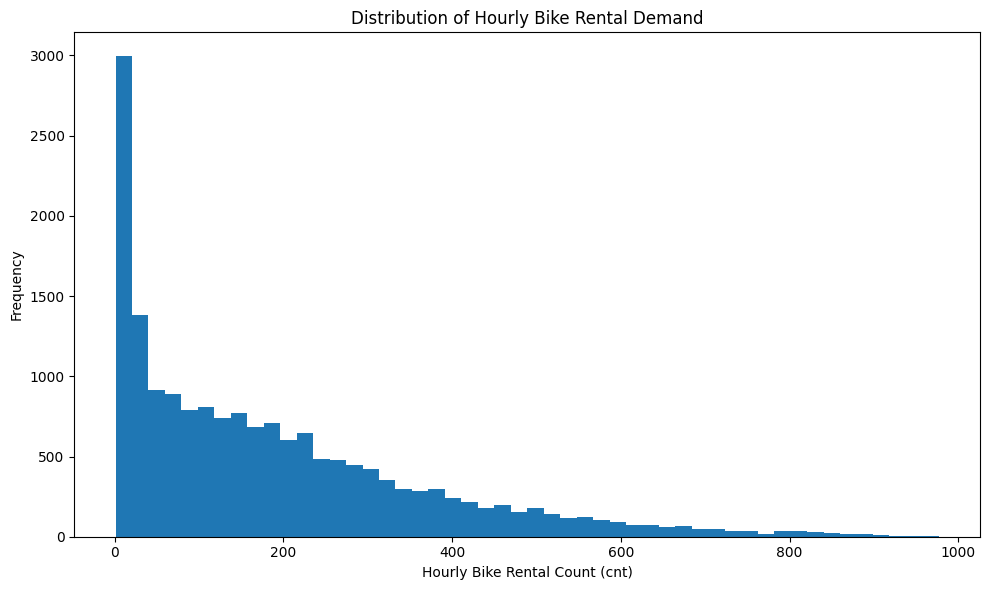

In [11]:
#visualizations
#distribution of cnt

plt.figure(figsize=(10, 6))
plt.hist(df["cnt"], bins=50)
plt.xlabel("Hourly Bike Rental Count (cnt)")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Bike Rental Demand")
plt.tight_layout()
plt.show()

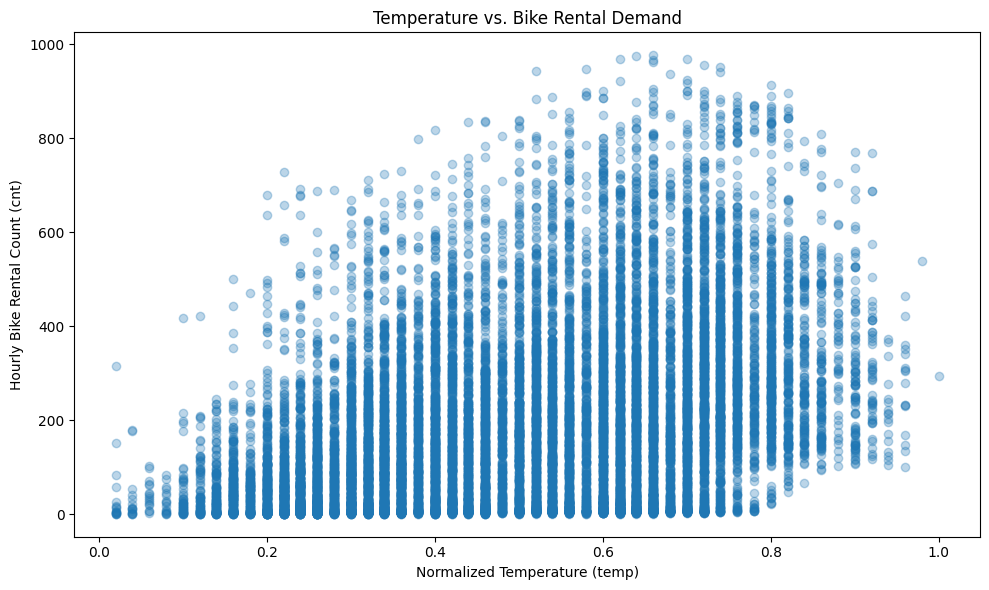

In [12]:
#Temperature vs target

plt.figure(figsize=(10, 6))
plt.scatter(
    df["temp"],
    df["cnt"],
    alpha=0.3
)
plt.xlabel("Normalized Temperature (temp)")
plt.ylabel("Hourly Bike Rental Count (cnt)")
plt.title("Temperature vs. Bike Rental Demand")
plt.tight_layout()
plt.show()

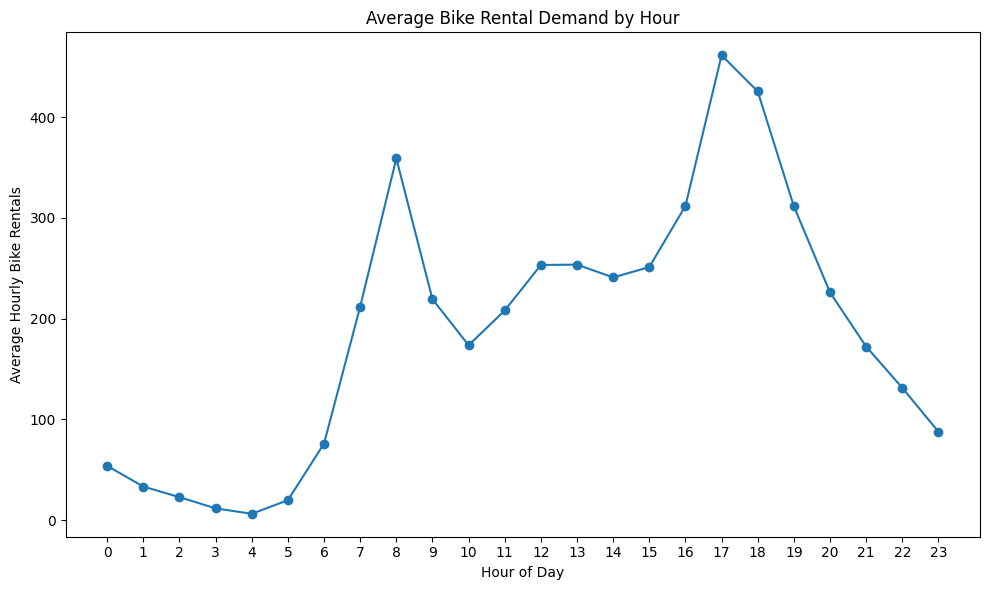

In [13]:
# Hour of day vs target

hourly_demand = df.groupby("hr")["cnt"].mean()
plt.figure(figsize=(10, 6))
plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Bike Rentals")
plt.title("Average Bike Rental Demand by Hour")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

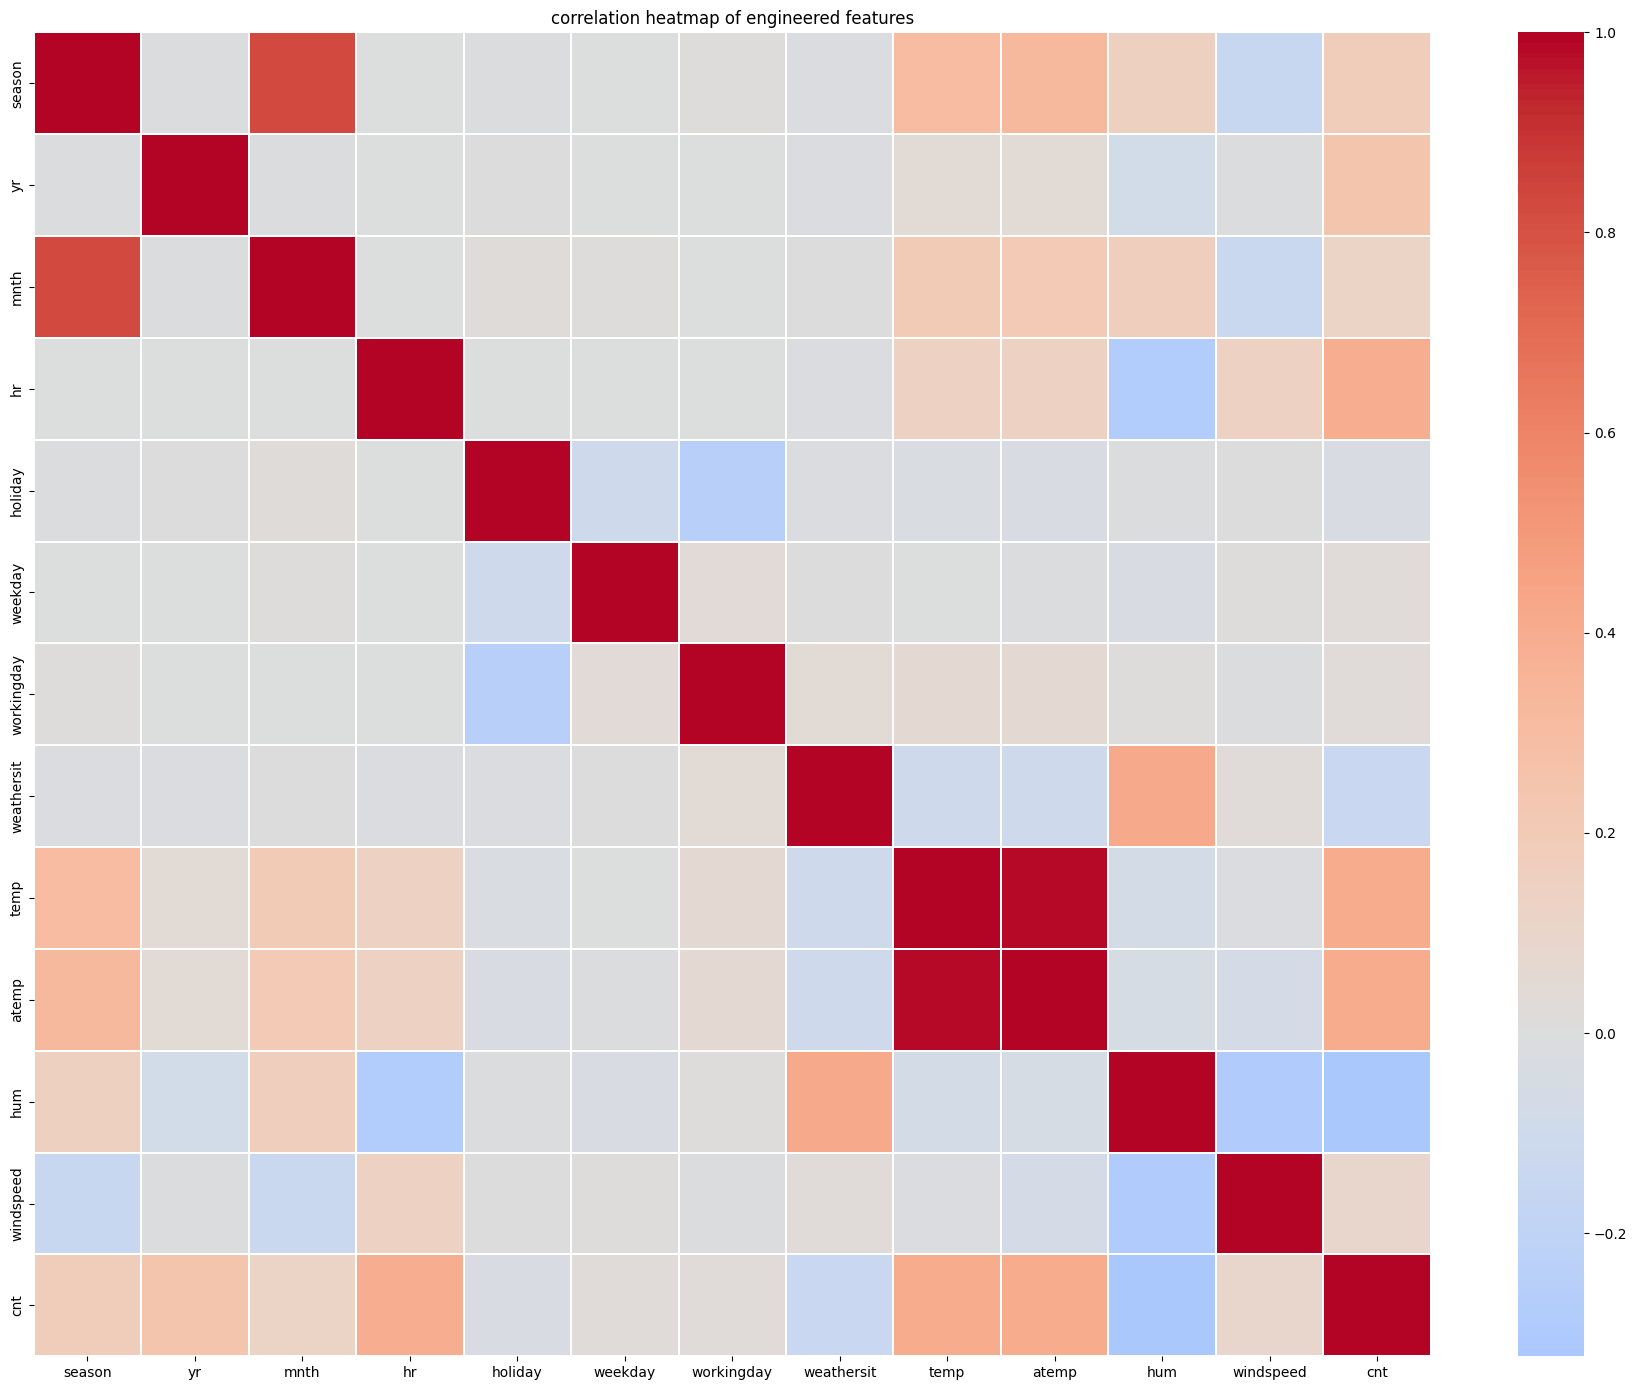

In [14]:
correlation_columns = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(18,14))
sns.heatmap(correlation_matrix,cmap="coolwarm",center=0,linewidths=0.2)
plt.title("correlation heatmap of engineered features")
plt.tight_layout()
plt.show()

In [15]:
# Compare raw integer hr vs one-hot encoded hr

def build_q11_features(hr_encoding="onehot"):
    x_base = x_raw.drop(columns=["workingday"]).copy()
    categorical_features = [
        "season",
        "mnth",
        "holiday",
        "weekday",
        "weathersit"
    ]
    # Encode hr only for the one-hot model
    if hr_encoding == "onehot":
        categorical_features.append("hr")
    x_features = pd.get_dummies(
        x_base,
        columns=categorical_features,
        drop_first=True,
        dtype=float
    )
    # Same five interaction terms for both models
    x_features["hr8_weather1"] = (
        (x_raw["hr"] == 8) &
        (x_raw["weathersit"] == 1)
    ).astype(float)
    x_features["hr17_weather1"] = (
        (x_raw["hr"] == 17) &
        (x_raw["weathersit"] == 1)
    ).astype(float)
    x_features["hr8_workingday"] = (
        (x_raw["hr"] == 8) &
        (x_raw["workingday"] == 1)
    ).astype(float)
    x_features["hr17_workingday"] = (
        (x_raw["hr"] == 17) &
        (x_raw["workingday"] == 1)
    ).astype(float)
    x_features["hr12_weather2"] = (
        (x_raw["hr"] == 12) &
        (x_raw["weathersit"] == 2)
    ).astype(float)
    return x_features


x_q11_onehot = build_q11_features("onehot")
x_q11_raw = build_q11_features("raw")

print("One-hot hr shape:", x_q11_onehot.shape)
print("Raw hr shape:", x_q11_raw.shape)

One-hot hr shape: (17379, 57)
Raw hr shape: (17379, 35)


In [16]:
# Reuse the exact same train/validation split

train_idx = x_train.index
val_idx = x_val.index
x_onehot_train = x_q11_onehot.loc[train_idx].copy()
x_onehot_val = x_q11_onehot.loc[val_idx].copy()
x_raw_train = x_q11_raw.loc[train_idx].copy()
x_raw_val = x_q11_raw.loc[val_idx].copy()

In [17]:
# Standardize continuous features using training statistics

q11_means = x_onehot_train[continuos_features].mean()
q11_stds = x_onehot_train[continuos_features].std()
for data in [x_onehot_train, x_onehot_val, x_raw_train, x_raw_val]:
    data[continuos_features] = (
        data[continuos_features] - q11_means
    ) / q11_stds

In [18]:
x_onehot_train_np = x_onehot_train.to_numpy(dtype=float)
x_onehot_val_np = x_onehot_val.to_numpy(dtype=float)

x_raw_train_np = x_raw_train.to_numpy(dtype=float)
x_raw_val_np = x_raw_val.to_numpy(dtype=float)

# Add intercept
x_onehot_train_np = np.column_stack([
    np.ones(x_onehot_train_np.shape[0]),
    x_onehot_train_np
])
x_onehot_val_np = np.column_stack([
    np.ones(x_onehot_val_np.shape[0]),
    x_onehot_val_np
])
x_raw_train_np = np.column_stack([
    np.ones(x_raw_train_np.shape[0]),
    x_raw_train_np
])
x_raw_val_np = np.column_stack([
    np.ones(x_raw_val_np.shape[0]),
    x_raw_val_np
])

In [19]:
def predict_linear_regression(x, weights):
  return x @ weights

def rmse(y_true,y_pred):
  return np.sqrt(np.mean((y_true-y_pred)**2))

In [20]:
# Normal Equation (closed form)

def normal_equation(x, y):
    return np.linalg.solve(x.T @ x, x.T @ y)

# Fit raw-hour model
weights_raw_hr = normal_equation(
    x_raw_train_np,
    y_train.to_numpy()
)

# Fit one-hot-hour model
weights_onehot_hr = normal_equation(
    x_onehot_train_np,
    y_train.to_numpy()
)

In [21]:
# Predictions
y_val_pred_raw_hr = predict_linear_regression(
    x_raw_val_np,
    weights_raw_hr
)
y_val_pred_onehot_hr = predict_linear_regression(
    x_onehot_val_np,
    weights_onehot_hr
)
# Validation RMSE
rmse_raw_hr = rmse(
    y_val.to_numpy(),
    y_val_pred_raw_hr
)
rmse_onehot_hr = rmse(
    y_val.to_numpy(),
    y_val_pred_onehot_hr
)
print("Raw hr validation RMSE:", rmse_raw_hr)
print("One-hot hr validation RMSE:", rmse_onehot_hr)

Raw hr validation RMSE: 119.71241606706211
One-hot hr validation RMSE: 93.09531545971274


In [22]:
print("\nHour Representation Comparison")
print("-" * 50)

print(f"Raw integer hr     : {rmse_raw_hr:.4f}")
print(f"One-hot encoded hr : {rmse_onehot_hr:.4f}")

print(f"\nRMSE improvement from one-hot: "
      f"{rmse_raw_hr - rmse_onehot_hr:.4f}")

print("\nDesign matrix columns:")
print("Raw hr model:", x_q11_raw.shape[1])
print("One-hot hr model:", x_q11_onehot.shape[1])


Hour Representation Comparison
--------------------------------------------------
Raw integer hr     : 119.7124
One-hot encoded hr : 93.0953

RMSE improvement from one-hot: 26.6171

Design matrix columns:
Raw hr model: 35
One-hot hr model: 57


In [23]:
# continue with the 1.3 implementations after the 1.1 ablation study
# add a column of ones for the intercept / bias

x_train = np.column_stack([np.ones(x_train_np.shape[0]), x_train_np])
x_val = np.column_stack([np.ones(x_val_np.shape[0]), x_val_np])
x_test = np.column_stack([np.ones(x_test_np.shape[0]), x_test_np])

print("new x_train shape:", x_train.shape)
print("new x_val shape:", x_val.shape)
print("new x_test shape:", x_test.shape)

new x_train shape: (13903, 58)
new x_val shape: (1738, 58)
new x_test shape: (1738, 58)


In [24]:
#conditional numbers for matrix x and x^t x

condition_x = np.linalg.cond(x_train)
xtx = x_train.T @ x_train
condition_xtx = np.linalg.cond(xtx)

print("Condition number of x:", condition_x)
print("Condition number of x^T x:", condition_xtx)

Condition number of x: 100.4324685424116
Condition number of x^T x: 10086.68073752245


Here for the conditional numbers at first we have got a really massive number and open inspection found the features matrix is 58 in dimentions(features) but its rank is 5 which means there is 1 directly linear dependency and by furthur inspection found that aput by feature design the column workingday is highly irrelevant and linear dependent due to the weekday giving a more granular info but working still gives the treand info so it is being ussed in the interactiove features

In [25]:
#closed form solution
# beta = (X^T * X)^-1 * X^T * y

xtx = x_train.T @ x_train
xty = x_train.T @ y_train
beta_closed = np.linalg.inv(xtx) @ xty

print("Number of weights:", len(beta_closed))
print("First 10 weights:")
print(beta_closed[:10])

Number of weights: 58
First 10 weights:
[ -8.45410843  85.1432644   21.53013566  21.04961102 -15.39045833
  -3.52061154  37.49326446  29.64309858  66.84237699   3.99397815]


In [26]:
y_train_pred_closed = predict_linear_regression(x_train, beta_closed)
train_rmse_closed = rmse(y_train, y_train_pred_closed)
print("closed form training RMSE:", train_rmse_closed)

y_val_pred_closed = predict_linear_regression(x_val, beta_closed)
val_rmse_closed = rmse(y_val, y_val_pred_closed)
print("closed form validation RMSE:", val_rmse_closed)

closed form training RMSE: 93.06860957469993
closed form validation RMSE: 93.09531545971272


In [27]:
# Standardization and learning rate ablation

# Unstandardized data:
# x_train and x_val already contain the intercept
x_train_unscaled_np = x_train.copy()
x_val_unscaled_np = x_val.copy()

# Standardized data:
# x_train_scaled and x_val_scaled do not contain the intercept
x_train_standardized_np = x_train_scaled.to_numpy(dtype=float)
x_val_standardized_np = x_val_scaled.to_numpy(dtype=float)

# Add intercept to standardized data
x_train_standardized_np = np.column_stack([
    np.ones(x_train_standardized_np.shape[0]),
    x_train_standardized_np
])

x_val_standardized_np = np.column_stack([
    np.ones(x_val_standardized_np.shape[0]),
    x_val_standardized_np
])

print("Unstandardized training:", x_train_unscaled_np.shape)
print("Standardized training:", x_train_standardized_np.shape)

Unstandardized training: (13903, 58)
Standardized training: (13903, 58)


In [28]:
#Gradient Descent approach

def batch_gradient_descent(x,y,learning_rate=0.01,max_iterations=1000,tolerance=1e-8):
  n_samples, n_features = x.shape
  weights = np.zeros(n_features) #initialize weights
  loss_history = []
  for iteration in range(max_iterations):
    predictions = x @ weights
    error = predictions - y
    loss = np.mean(error**2)/2
    loss_history.append(loss)
    gradient = (x.T @ error)/n_samples
    new_weights = weights - learning_rate * gradient
    if tolerance is not None:
      if np.linalg.norm(new_weights - weights) < tolerance:
        weights = new_weights
        break
    weights = new_weights
  return  weights, loss_history, iteration + 1

In [29]:
#learning rate ablation

learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]

max_iterations_ablation = 1000
results_unstandardized = {}
results_standardized = {}
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
for lr in learning_rates:
    # Unstandardized
    weights_unscaled, loss_unscaled, iterations_unscaled = (
        batch_gradient_descent(
            x_train_unscaled_np,
            y_train_np,
            learning_rate=lr,
            max_iterations=max_iterations_ablation,
            tolerance=None
        )
    )
    # Standardized
    weights_scaled, loss_scaled, iterations_scaled = (
        batch_gradient_descent(
            x_train_standardized_np,
            y_train_np,
            learning_rate=lr,
            max_iterations=max_iterations_ablation,
            tolerance=None
        )
    )
    results_unstandardized[lr] = {
        "weights": weights_unscaled,
        "loss": loss_unscaled
    }
    results_standardized[lr] = {
        "weights": weights_scaled,
        "loss": loss_scaled
    }
print("Learning-rate experiments completed.")

Learning-rate experiments completed.


In [30]:
def check_stability(loss_history):

    loss_history = np.asarray(loss_history)
    if not np.all(np.isfinite(loss_history)):
        return False
    if loss_history[-1] > loss_history[0] * 100:
        return False
    if loss_history[-1] >= loss_history[0]:
        return False

    return True

print("Unstandardized learning rates:")
for lr in learning_rates:
    stable = check_stability(results_unstandardized[lr]["loss"])
    print(f"LR = {lr:<7} Stable = {stable}")

print("\nStandardized learning rates:")
for lr in learning_rates:
    stable = check_stability(results_standardized[lr]["loss"])
    print(f"LR = {lr:<7} Stable = {stable}")

Unstandardized learning rates:
LR = 1e-05   Stable = True
LR = 0.0001  Stable = True
LR = 0.001   Stable = True
LR = 0.01    Stable = True
LR = 0.1     Stable = True
LR = 1.0     Stable = False

Standardized learning rates:
LR = 1e-05   Stable = True
LR = 0.0001  Stable = True
LR = 0.001   Stable = True
LR = 0.01    Stable = True
LR = 0.1     Stable = True
LR = 1.0     Stable = False


In [31]:
stable_unstandardized = [
    lr for lr in learning_rates
    if check_stability(results_unstandardized[lr]["loss"])
]
stable_standardized = [
    lr for lr in learning_rates
    if check_stability(results_standardized[lr]["loss"])
]
largest_stable_unstandardized = (
    max(stable_unstandardized)
    if stable_unstandardized else None
)
largest_stable_standardized = (
    max(stable_standardized)
    if stable_standardized else None
)
print("Largest stable LR without standardization:",
      largest_stable_unstandardized)
print("Largest stable LR with standardization:",
      largest_stable_standardized)

Largest stable LR without standardization: 0.1
Largest stable LR with standardization: 0.1


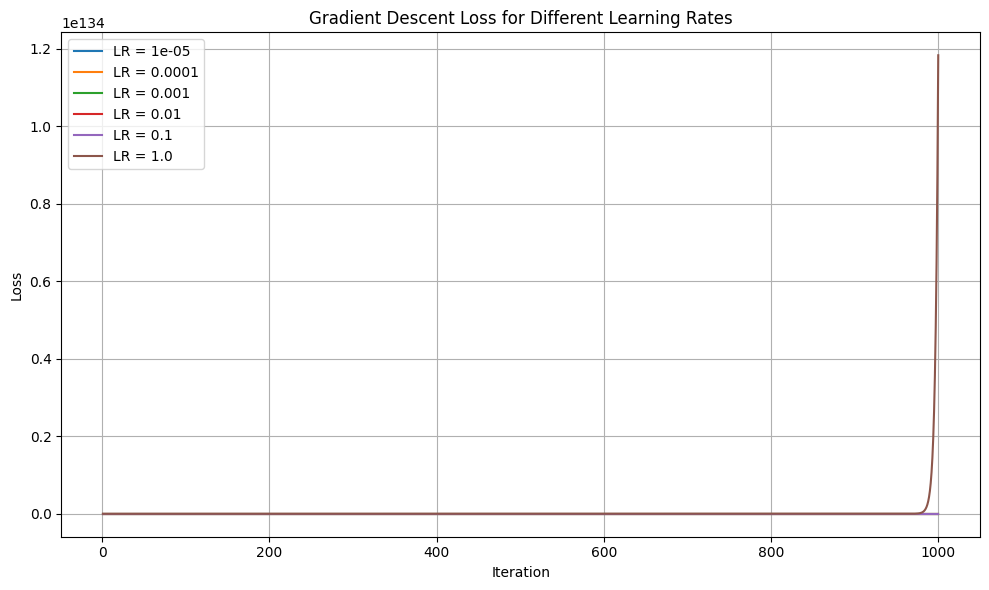

In [32]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    loss_history = results_standardized[lr]["loss"]

    plt.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        label=f"LR = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
common_stable_lrs = sorted(
    set(stable_unstandardized) &
    set(stable_standardized)
)

print("Learning rates stable for both:")
print(common_stable_lrs)

Learning rates stable for both:
[1e-05, 0.0001, 0.001, 0.01, 0.1]


In [34]:
if common_stable_lrs:

    common_lr = max(common_stable_lrs)
    print("Largest learning rate stable for both:", common_lr)
    # Run until convergence
    weights_unscaled_conv, loss_unscaled_conv, iterations_unscaled_conv = (
        batch_gradient_descent(
            x_train_unscaled_np,
            y_train_np,
            learning_rate=common_lr,
            max_iterations=50000,
            tolerance=1e-8
        )
    )
    weights_scaled_conv, loss_scaled_conv, iterations_scaled_conv = (
        batch_gradient_descent(
            x_train_standardized_np,
            y_train_np,
            learning_rate=common_lr,
            max_iterations=50000,
            tolerance=1e-8
        )
    )
    print(
        "\nIterations to converge without standardization:",
        iterations_unscaled_conv
    )
    print(
        "Iterations to converge with standardization:",
        iterations_scaled_conv
    )
else:
    print("No common stable learning rate found.")

Largest learning rate stable for both: 0.1

Iterations to converge without standardization: 50000
Iterations to converge with standardization: 50000


At the largest learning rate stable for both standardized and unstandardized features (α = 0.1), neither run reached the specified tolerance of 1e-8 within the maximum 50,000 iterations. Therefore, both runs terminated because the maximum iteration limit was reached rather than because the convergence criterion was satisfied.

In [35]:
gd_weights, loss_history, gd_iterations = batch_gradient_descent(
    x_train,
    y_train,
    learning_rate=0.01,
    max_iterations=50000,
    tolerance=1e-8
)

print("Gradient Descent iterations:", gd_iterations)

Gradient Descent iterations: 50000


In [36]:
y_train_pred_gd = predict_linear_regression(x_train, gd_weights)
y_val_pred_gd = predict_linear_regression(x_val, gd_weights)
train_rmse_gd = rmse(y_train, y_train_pred_gd)
val_rmse_gd = rmse(y_val, y_val_pred_gd)

print("Gradient Descent training RMSE:", train_rmse_gd)
print("Gradient Descent validation RMSE:", val_rmse_gd)

Gradient Descent training RMSE: 93.52732381760333
Gradient Descent validation RMSE: 93.59017342398944


In [37]:
# comparing closed form implementation and gradiefnt descent

weight_difference = np.max(np.abs(beta_closed - gd_weights))
print(
    "Maximum absolute difference between "
    "closed-form and GD weights:",
    weight_difference
)

Maximum absolute difference between closed-form and GD weights: 59.25955548662403


polynomial features and the bias variance tradeoffs


In [38]:
bike_comfort = pd.read_csv("/content/bike_temp_comfort_zone.csv")
print("Dataset shape:", bike_comfort.shape)
display(bike_comfort.head())

Dataset shape: (800, 3)


,temp,demand,split
0,0.9583,278.7,train
1,0.7005,348.1,val
2,0.3719,214.0,train
3,0.6742,498.2,test
4,0.4661,391.2,train


In [39]:
train_data = bike_comfort[bike_comfort["split"] == "train"].copy()
val_data = bike_comfort[bike_comfort["split"] == "val"].copy()
test_data = bike_comfort[bike_comfort["split"] == "test"].copy()

x_poly_train = train_data["temp"].to_numpy(dtype=float)
y_poly_train = train_data["demand"].to_numpy(dtype=float)

x_poly_val = val_data["temp"].to_numpy(dtype=float)
y_poly_val = val_data["demand"].to_numpy(dtype=float)

x_poly_test = test_data["temp"].to_numpy(dtype=float)
y_poly_test = test_data["demand"].to_numpy(dtype=float)

print("Training:", x_poly_train.shape, y_poly_train.shape)
print("Validation:", x_poly_val.shape, y_poly_val.shape)
print("Test:", x_poly_test.shape, y_poly_test.shape)

Training: (400,) (400,)
Validation: (200,) (200,)
Test: (200,) (200,)


In [40]:
# create polynomial feature function

def create_polynomial_features(x, degree):
  return np.column_stack([
      x**power for power in range(degree + 1)
  ])

In [41]:
# standardize the polynomial powers

def standardize_polynomial_features(x_train,x_val,x_test,degree):
  X_train = create_polynomial_features(x_train,degree)
  X_val = create_polynomial_features(x_val,degree)
  X_test = create_polynomial_features(x_test,degree)

  #do not standardize intercept column
  train_mean = X_train[:, 1:].mean(axis=0)
  train_std = X_train[:, 1:].std(axis=0)

  X_train[:, 1:] = (X_train[:, 1:] - train_mean) / train_std
  X_val[:, 1:] = (X_val[:, 1:] - train_mean) / train_std
  X_test[:, 1:] = (X_test[:, 1:] - train_mean) / train_std

  return X_train, X_val, X_test

In [42]:
degrees = range(1,13)
train_rmse_poly=[]
val_rmse_poly=[]
test_rmse_poly=[]

all_weights_poly={}

for degree in degrees:
  X_train,X_val,X_test = standardize_polynomial_features(x_poly_train,x_poly_val,x_poly_test,degree)

  weights = normal_equation(X_train,y_poly_train)

  y_train_pred_poly = predict_linear_regression(X_train,weights)
  y_val_pred_poly = predict_linear_regression(X_val,weights)
  y_test_pred_poly = predict_linear_regression(X_test,weights)

  train_rmse = rmse(y_poly_train,y_train_pred_poly)
  val_rmse = rmse(y_poly_val,y_val_pred_poly)
  test_rmse = rmse(y_poly_test,y_test_pred_poly)

  train_rmse_poly.append(train_rmse)
  val_rmse_poly.append(val_rmse)
  test_rmse_poly.append(test_rmse)

  all_weights_poly[degree] = weights

print("Polynomial regression complete for degrees 1-12")

Polynomial regression complete for degrees 1-12


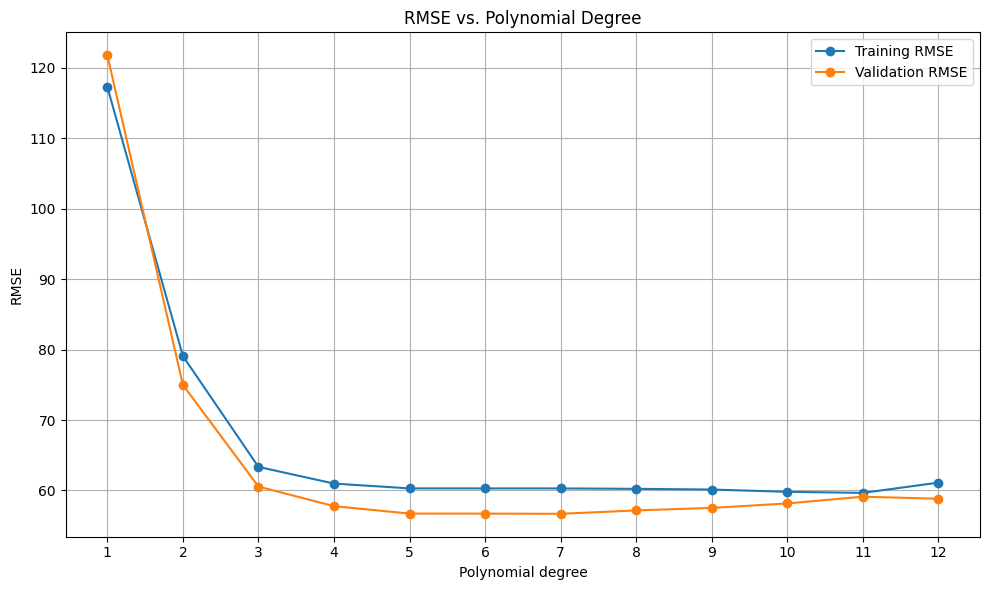

In [43]:
#visualize

plt.figure(figsize=(10, 6))

plt.plot(list(degrees),train_rmse_poly,marker="o",label="Training RMSE")
plt.plot(list(degrees),val_rmse_poly,marker="o",label="Validation RMSE")

plt.xlabel("Polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs. Polynomial Degree")
plt.xticks(list(degrees))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
poly_results = pd.DataFrame({
    "Degree": list(degrees),
    "Training RMSE": train_rmse_poly,
    "Validation RMSE": val_rmse_poly
})
display(poly_results)

,Degree,Training RMSE,Validation RMSE
0,1,117.286843,121.769875
1,2,79.082943,74.987688
2,3,63.348213,60.557225
3,4,60.977979,57.773170
4,5,60.296579,56.719809
5,6,60.292042,56.713951
6,7,60.290184,56.690702
7,8,60.234848,57.172054
8,9,60.133104,57.526858
9,10,59.809638,58.160283


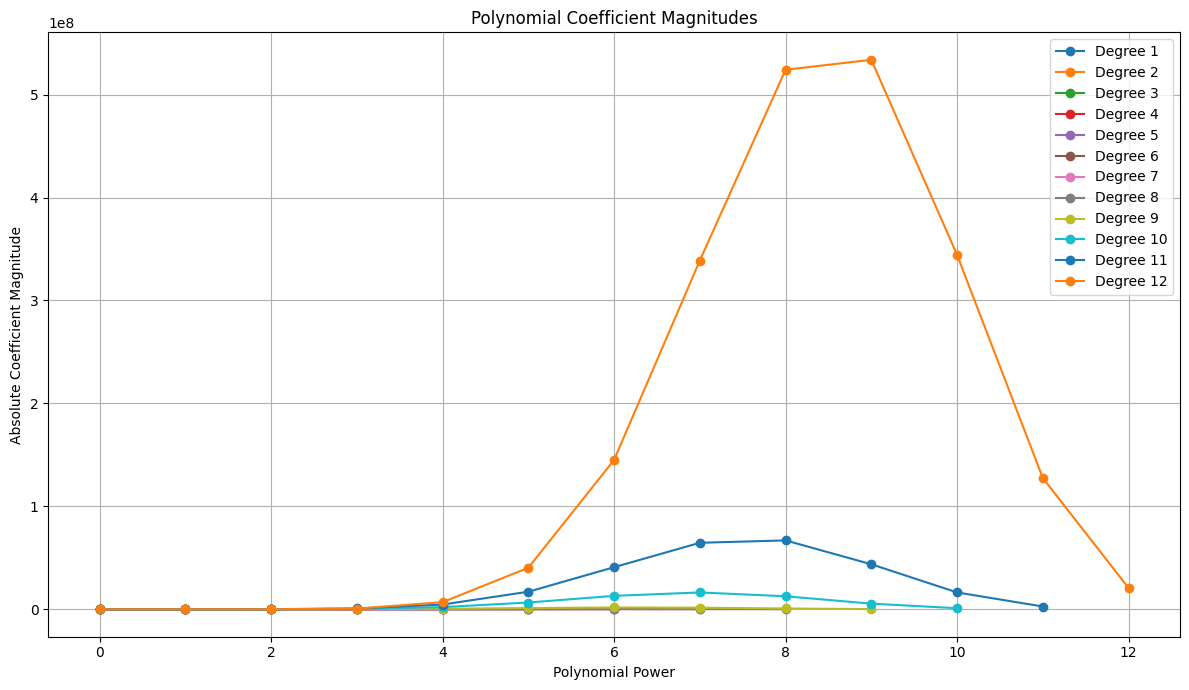

In [45]:
plt.figure(figsize=(12, 7))
for degree in degrees:
    weights = all_weights_poly[degree]
    powers = np.arange(len(weights))
    plt.plot(
        powers,
        np.abs(weights),
        marker="o",
        label=f"Degree {degree}"
    )

plt.xlabel("Polynomial Power")
plt.ylabel("Absolute Coefficient Magnitude")
plt.title("Polynomial Coefficient Magnitudes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# best degree with ther lowest validation error by test rmse

validation_region=range(4,9)
region_val_rmse={
    degree: val_rmse_poly[degree-1]
    for degree in validation_region
}
best_degree = min(region_val_rmse, key=region_val_rmse.get)

best_val_rmse = val_rmse_poly[best_degree-1]
best_test_rmse = test_rmse_poly[best_degree-1]

print("validation region:" "4-8")
print("best degree:", best_degree)
print("best validation RMSE:", best_val_rmse)
print("Test RMSE:", best_test_rmse)

validation region:4-8
best degree: 7
best validation RMSE: 56.6907022122356
Test RMSE: 52.614200534228175


## Ridge Regression

Ridge regression is implemented from scratch using the closed-form solution

\[
\hat{\beta} = (X^TX + \lambda I)^{-1}X^Ty
\]

where the intercept term is not penalized. For \(\lambda=0\), the least-squares solution is obtained using `np.linalg.lstsq`.

The Ridge model is evaluated using:
1. The complete training set.
2. A random 100-row training subset.

For the 100-row subset, any zero-variance features are removed before fitting the model.

In [62]:
def ridge_regression(X,y,lam):
  n_features = X.shape[1]
  if lam == 0:
    weights, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return weights

  penalty = np.eye(n_features)
  penalty[0,0] = 0.0
  A=X.T @ X + lam*penalty
  b=X.T @ y

  weights = np.linalg.solve(A,b)
  return weights

In [76]:
lambdas = np.concatenate([
    [0.0],
    np.logspace(-4,5,10)
])
print("Lambdas:", lambdas)

Lambdas: [0.e+00 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04
 1.e+05]


In [77]:
# full training set sweep
ridge_full_results = []
for lam in lambdas:
  weights=ridge_regression(x_train,y_train.to_numpy(dtype=float),lam)
  train_predictions = predict_linear_regression(x_train, weights)
  val_predictions = predict_linear_regression(x_val, weights)
  train_error = rmse(y_train, train_predictions)
  val_error = rmse(y_val, val_predictions)
  ridge_full_results.append({
      "lambda": lam,
      "train_rmse": train_error,
      "val_rmse": val_error,
      "weights": weights
  })

print("Full training set ridge sweep done")

Full training set ridge sweep done


In [78]:
# smaple subset sweeps
rng = np.random.default_rng(seed)
subset_indices = rng.choice(len(x_train),size=100,replace=False)
x_train_100 = x_train[subset_indices]
y_train_100 = y_train.to_numpy(dtype=float)[subset_indices]
print("100 row subset shape:", x_train_100.shape)

100 row subset shape: (100, 58)


In [79]:
# drop zero variance feeatures

subset_std = np.std(x_train_100, axis=0)
nonzero_variance_mask=np.ones(x_train_100.shape[1],dtype=bool)
nonzero_variance_mask[1:]=subset_std[1:]>0
x_train_100_reduced = x_train_100[:, nonzero_variance_mask]
x_val_100_reduced = x_val[:, nonzero_variance_mask]
print("original 100-row feature count:",x_train_100.shape[1])
print("reduced ferture count:",x_train_100_reduced.shape[1])
print("removed features which are 0 variance:", np.sum(~nonzero_variance_mask))

original 100-row feature count: 58
reduced ferture count: 57
removed features which are 0 variance: 1


In [80]:
# run ridge sweep usig the 100 row subset

ridge_100_results = []
for lam in lambdas:
    weights = ridge_regression(
        x_train_100_reduced,
        y_train_100,
        lam
    )
    train_predictions = predict_linear_regression(
        x_train_100_reduced,
        weights
    )
    val_predictions = predict_linear_regression(
        x_val_100_reduced,
        weights
    )
    train_error = rmse(
        y_train_100,
        train_predictions
    )
    val_error = rmse(
        y_val,
        val_predictions
    )
    ridge_100_results.append({
        "lambda": lam,
        "train_rmse": train_error,
        "val_rmse": val_error,
        "weights": weights
    })

print("100-row Ridge sweep done")

100-row Ridge sweep done


In [81]:
ridge_full_table = pd.DataFrame([
    {
        "Lambda": result["lambda"],
        "Training RMSE": result["train_rmse"],
        "Validation RMSE": result["val_rmse"]
    }
    for result in ridge_full_results
])
ridge_100_table = pd.DataFrame([
    {
        "Lambda": result["lambda"],
        "Training RMSE": result["train_rmse"],
        "Validation RMSE": result["val_rmse"]
    }
    for result in ridge_100_results
])
print("Full training set:")
display(ridge_full_table)

print("100-row subset:")
display(ridge_100_table)

Full training set:


,Lambda,Training RMSE,Validation RMSE
0,0.0000,93.068610,93.095315
1,0.0001,93.068610,93.095315
2,0.0010,93.068610,93.095316
3,0.0100,93.068610,93.095317
4,0.1000,93.068668,93.095382
5,1.0000,93.073930,93.100465
6,10.0000,93.374510,93.396832
7,100.0000,97.751905,97.846430
8,1000.0000,120.145128,121.209243
9,10000.0000,150.362031,151.743827


100-row subset:


,Lambda,Training RMSE,Validation RMSE
0,0.0000,61.127806,144.335725
1,0.0001,61.127811,144.309609
2,0.0010,61.128292,144.077371
3,0.0100,61.168424,141.999263
4,0.1000,62.514011,131.900465
5,1.0000,72.605212,126.096535
6,10.0000,96.643177,141.814387
7,100.0000,123.424911,159.164502
8,1000.0000,144.580618,174.935869
9,10000.0000,151.210815,180.115107


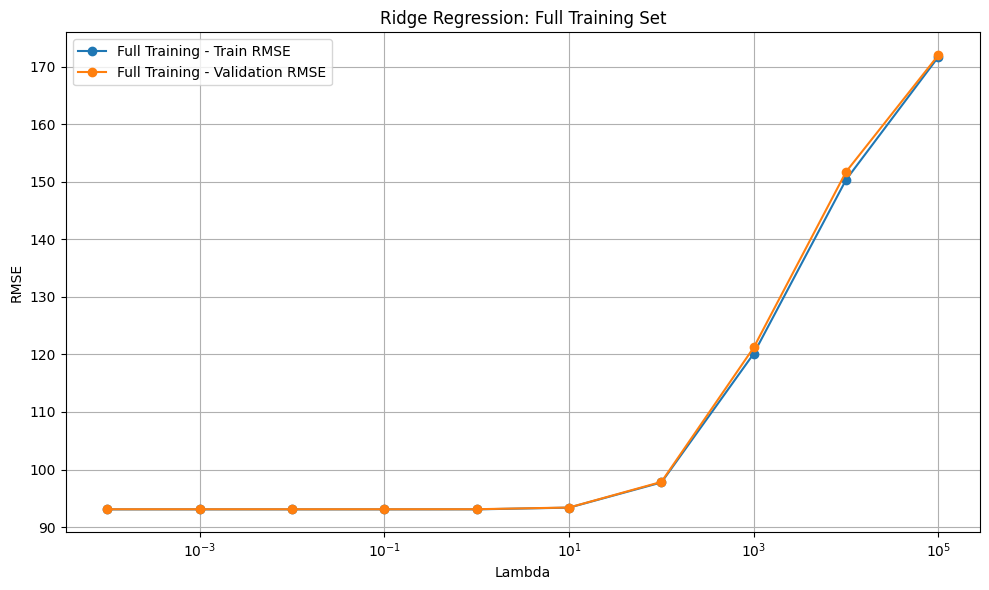

In [82]:
plt.figure(figsize=(10, 6))
plt.semilogx(
    ridge_full_table["Lambda"].replace(0, np.nan),
    ridge_full_table["Training RMSE"],
    marker="o",
    label="Full Training - Train RMSE"
)
plt.semilogx(
    ridge_full_table["Lambda"].replace(0, np.nan),
    ridge_full_table["Validation RMSE"],
    marker="o",
    label="Full Training - Validation RMSE"
)
plt.xlabel("Lambda")
plt.ylabel("RMSE")
plt.title("Ridge Regression: Full Training Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

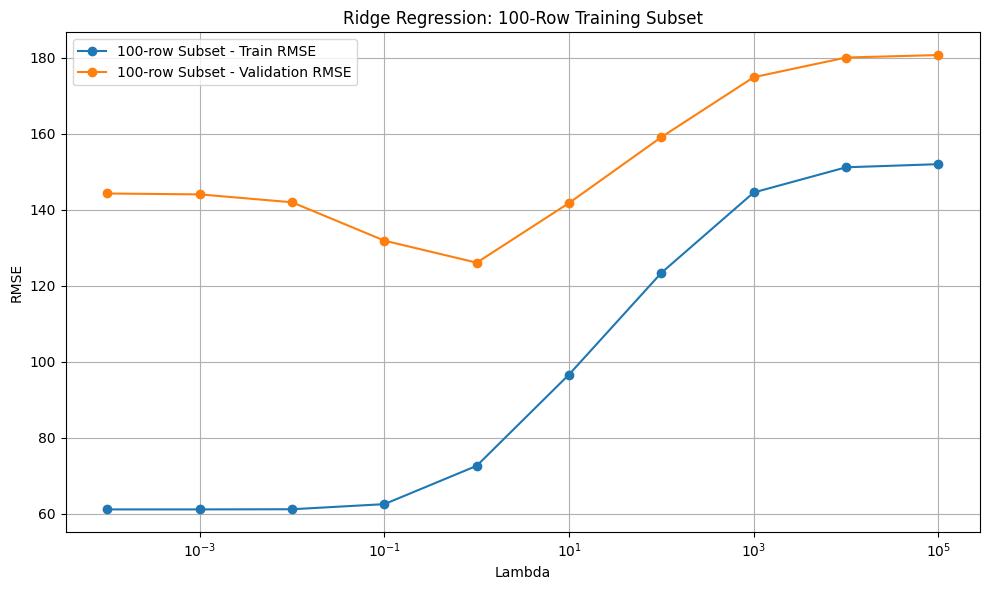

In [83]:
# Because λ=0 cannot be displayed on a log x-axis, the plots intentionally replace it with NaN.
# The tables still contain the λ=0 result.

plt.figure(figsize=(10, 6))
plt.semilogx(
    ridge_100_table["Lambda"].replace(0, np.nan),
    ridge_100_table["Training RMSE"],
    marker="o",
    label="100-row Subset - Train RMSE"
)
plt.semilogx(
    ridge_100_table["Lambda"].replace(0, np.nan),
    ridge_100_table["Validation RMSE"],
    marker="o",
    label="100-row Subset - Validation RMSE"
)
plt.xlabel("Lambda")
plt.ylabel("RMSE")
plt.title("Ridge Regression: 100-Row Training Subset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
# Select lambda using validation RMSE on the full training set

best_full_result = min(
    ridge_full_results,
    key=lambda result: result["val_rmse"]
)
best_lambda = best_full_result["lambda"]
best_ridge_weights = best_full_result["weights"]
print("Selected lambda:", best_lambda)
print("Training RMSE:", best_full_result["train_rmse"])
print("Validation RMSE:", best_full_result["val_rmse"])

Selected lambda: 0.0
Training RMSE: 93.06860957469993
Validation RMSE: 93.09531545971274


Evaluation on the Test Set

The Ridge regularization strength was selected using the validation RMSE
from the full training-set sweep. The selected model is evaluated on the
held-out test set using MAE, RMSE, R², and Pearson correlation

Metrics are calculated without clipping negative predictions, as required.
Although the target represents non-negative bike rental counts, a linear
model can produce negative predictions.

In [85]:
# Select the model using the best validation result
# from the full training-set Ridge sweep.

best_full_result = min(
    ridge_full_results,
    key=lambda result: result["val_rmse"]
)
best_lambda = best_full_result["lambda"]
best_ridge_weights = best_full_result["weights"]
# Test predictions
y_test_np = y_test.to_numpy(dtype=float)

y_test_pred_ridge = predict_linear_regression(
    x_test,
    best_ridge_weights
)

# MAE
test_mae = np.mean(
    np.abs(y_test_np - y_test_pred_ridge)
)

# RMSE
test_rmse = np.sqrt(
    np.mean((y_test_np - y_test_pred_ridge) ** 2)
)

# R-squared
ss_res = np.sum(
    (y_test_np - y_test_pred_ridge) ** 2
)
ss_tot = np.sum(
    (y_test_np - np.mean(y_test_np)) ** 2
)
test_r2 = 1 - (ss_res / ss_tot)

# Pearson correlation
test_pearson = np.corrcoef(
    y_test_np,
    y_test_pred_ridge
)[0, 1]

# Check negative predictions without clipping
negative_prediction_count = np.sum(
    y_test_pred_ridge < 0
)

print("Selected lambda:", best_lambda)
print("Number of negative predictions:", negative_prediction_count)

Selected lambda: 0.0
Number of negative predictions: 185


In [86]:
# Report the final metrics in a table

final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Pearson Correlation"
    ],
    "Value": [
        test_mae,
        test_rmse,
        test_r2,
        test_pearson
    ]
})

display(final_results)

,Metric,Value
0,MAE,69.135636
1,RMSE,92.152157
2,R²,0.752184
3,Pearson Correlation,0.867293


## 2. Radar Signal Classification with **SVM**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

from sklearn.model_selection import train_test_split, StratifiedKFold

username = "manoj.pentakota"
SEED = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

print(SEED)

2817696157


In [2]:
df = pd.read_csv("/content/ionosphere.data", header=None, skipinitialspace=True)
print(df.shape)
display(df.head())

(351, 35)


,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [3]:
feature_names = [f"a{i:02d}" for i in range(1, 35)]
df.columns = feature_names + ["target"]
# good = positive class (+1)
# bad = negative class (-1)
df["target"] = df["target"].map({
    "g": 1,
    "b": -1
})
print("Column names:")
print(df.columns.tolist())
print("\nTarget distribution:")
print(df["target"].value_counts())
display(df.head())

Column names:
['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19', 'a20', 'a21', 'a22', 'a23', 'a24', 'a25', 'a26', 'a27', 'a28', 'a29', 'a30', 'a31', 'a32', 'a33', 'a34', 'target']

Target distribution:
target
 1    225
-1    126
Name: count, dtype: int64


,a01,a02,a03,a04,a05,a06,a07,a08,a09,a10,...,a26,a27,a28,a29,a30,a31,a32,a33,a34,target
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,-1
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,-1
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1


In [4]:
feature_summary = df[feature_names].describe().T
feature_summary["n_unique"] = df[feature_names].nunique()
feature_summary["variance"] = df[feature_names].var()
display(feature_summary)

,count,mean,std,min,25%,50%,75%,max,n_unique,variance
a01,351.0,0.891738,0.311155,0.0,1.000000,1.00000,1.000000,1.0,2,0.096817
a02,351.0,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.0,1,0.000000
a03,351.0,0.641342,0.497708,-1.0,0.472135,0.87111,1.000000,1.0,219,0.247713
a04,351.0,0.044372,0.441435,-1.0,-0.064735,0.01631,0.194185,1.0,269,0.194865
a05,351.0,0.601068,0.519862,-1.0,0.412660,0.80920,1.000000,1.0,204,0.270256
a06,351.0,0.115889,0.460810,-1.0,-0.024795,0.02280,0.334655,1.0,259,0.212346
a07,351.0,0.550095,0.492654,-1.0,0.211310,0.72873,0.969240,1.0,231,0.242708
a08,351.0,0.119360,0.520750,-1.0,-0.054840,0.01471,0.445675,1.0,260,0.271180
a09,351.0,0.511848,0.507066,-1.0,0.087110,0.68421,0.953240,1.0,244,0.257115
a10,351.0,0.181345,0.483851,-1.0,-0.048075,0.01829,0.534195,1.0,267,0.234112


In [5]:
constant_columns = []
for column in feature_names:
    unique_values = df[column].nunique()
    variance = df[column].var()
    if unique_values <= 1 or np.isclose(variance, 0):
        constant_columns.append(column)

print("no-information columns:", constant_columns)
print("number of no-information columns:", len(constant_columns))

no-information columns: ['a02']
number of no-information columns: 1


In [6]:
retained_features = [
    column for column in feature_names
    if column not in constant_columns
]
X = df[retained_features].to_numpy(dtype=float)
y = df["target"].to_numpy(dtype=int)

print("original number of features:", len(feature_names))
print("removed features:", constant_columns)
print("number of retained features:", len(retained_features))
print("feature matrix shape:", X.shape)
print("target shape:", y.shape)

original number of features: 34
removed features: ['a02']
number of retained features: 33
feature matrix shape: (351, 33)
target shape: (351,)


the constant feature are dea;th with and removed and keeping them can cause zero standard deviation during standardization and may create problem in kernel calculaitions

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])
print("\nTraining feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

Training samples: 280
Test samples: 71

Training feature shape: (280, 33)
Test feature shape: (71, 33)


In [8]:
def display_class_distribution(y_values, dataset_name):
    positive_count = np.sum(y_values == 1)
    negative_count = np.sum(y_values == -1)

    print(f"{dataset_name}:")
    print("  Positive (good):", positive_count)
    print("  Negative (bad):", negative_count)
    print("  Total:", len(y_values))
    print()

display_class_distribution(y_train, "Training set")
display_class_distribution(y_test, "Test set")

Training set:
  Positive (good): 179
  Negative (bad): 101
  Total: 280

Test set:
  Positive (good): 46
  Negative (bad): 25
  Total: 71



In [9]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)
fold_information = []
for fold_number, (train_indices, validation_indices) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    y_fold_train = y_train[train_indices]
    y_fold_validation = y_train[validation_indices]
    fold_information.append({
        "Fold": fold_number,
        "Train samples": len(train_indices),
        "Validation samples": len(validation_indices),
        "Train positive": np.sum(y_fold_train == 1),
        "Train negative": np.sum(y_fold_train == -1),
        "Validation positive": np.sum(y_fold_validation == 1),
        "Validation negative": np.sum(y_fold_validation == -1)
    })

fold_df = pd.DataFrame(fold_information)
display(fold_df)

,Fold,Train samples,Validation samples,Train positive,Train negative,Validation positive,Validation negative
0,1,224,56,143,81,36,20
1,2,224,56,143,81,36,20
2,3,224,56,143,81,36,20
3,4,224,56,143,81,36,20
4,5,224,56,144,80,35,21


The data was split into five folds using StratifiedKFold with shuffling and
random seed 42. Stratification preserves approximately the same positive and
negative class proportions in every fold. Each fold is used once for validation
while the remaining four folds are used for training.

In [10]:
# Standarization

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

# Apply the same training statistics to both datasets
X_train_standardized = (X_train - train_mean) / train_std
X_test_standardized = (X_test - train_mean) / train_std

print("Training standardized shape:", X_train_standardized.shape)
print("Test standardized shape:", X_test_standardized.shape)

print("\nFirst five feature means in standardized training data:")
print(X_train_standardized.mean(axis=0)[:5])

print("\nFirst five feature standard deviations:")
print(X_train_standardized.std(axis=0)[:5])

Training standardized shape: (280, 33)
Test standardized shape: (71, 33)

First five feature means in standardized training data:
[-3.58443434e-16  1.15780401e-16  8.24737104e-17  5.24580379e-16
  0.00000000e+00]

First five feature standard deviations:
[1. 1. 1. 1. 1.]


stadardization ensure the features with huge values do not dominate the linear svm optimization. It is also important for kernels because
the polynomial and RBF kernels depend on dot products or distances between
feature vectors.

In [11]:
def standardize_fold(X_fold_train, X_fold_validation):
    fold_mean = X_fold_train.mean(axis=0)
    fold_std = X_fold_train.std(axis=0)
    fold_std[fold_std == 0] = 1.0
    X_fold_train_scaled = (
        X_fold_train - fold_mean
    ) / fold_std
    X_fold_validation_scaled = (
        X_fold_validation - fold_mean
    ) / fold_std

    return X_fold_train_scaled, X_fold_validation_scaled

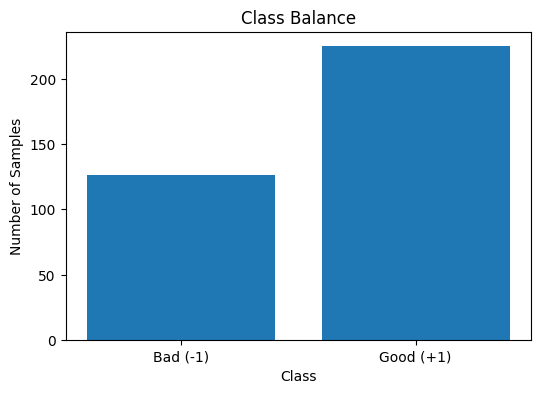

In [12]:
class_labels = ["Bad (-1)", "Good (+1)"]
class_counts = [
    np.sum(y == -1),
    np.sum(y == 1)
]
plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts)
plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

The class balance plot shows the number of good and bad radar returns and
helps identify whether a majority-class classifier could achieve a deceptively
high accuracy.

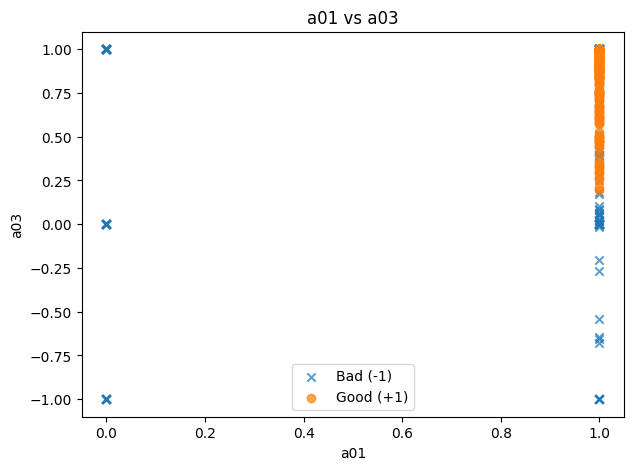

In [13]:
# Select the first two retained features
feature_1 = retained_features[0]
feature_2 = retained_features[1]

feature_1_index = retained_features.index(feature_1)
feature_2_index = retained_features.index(feature_2)

plt.figure(figsize=(7, 5))

for label, class_name, marker in [
    (-1, "Bad (-1)", "x"),
    (1, "Good (+1)", "o")
]:
    mask = y == label
    plt.scatter(
        X[mask, feature_1_index],
        X[mask, feature_2_index],
        label=class_name,
        marker=marker,
        alpha=0.7
    )

plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title(f"{feature_1} vs {feature_2}")
plt.legend()
plt.show()

The scatter plot provides a two-dimensional view of the relationship between
two features and shows whether the two classes appear to overlap or be
separable using a simple linear boundary.

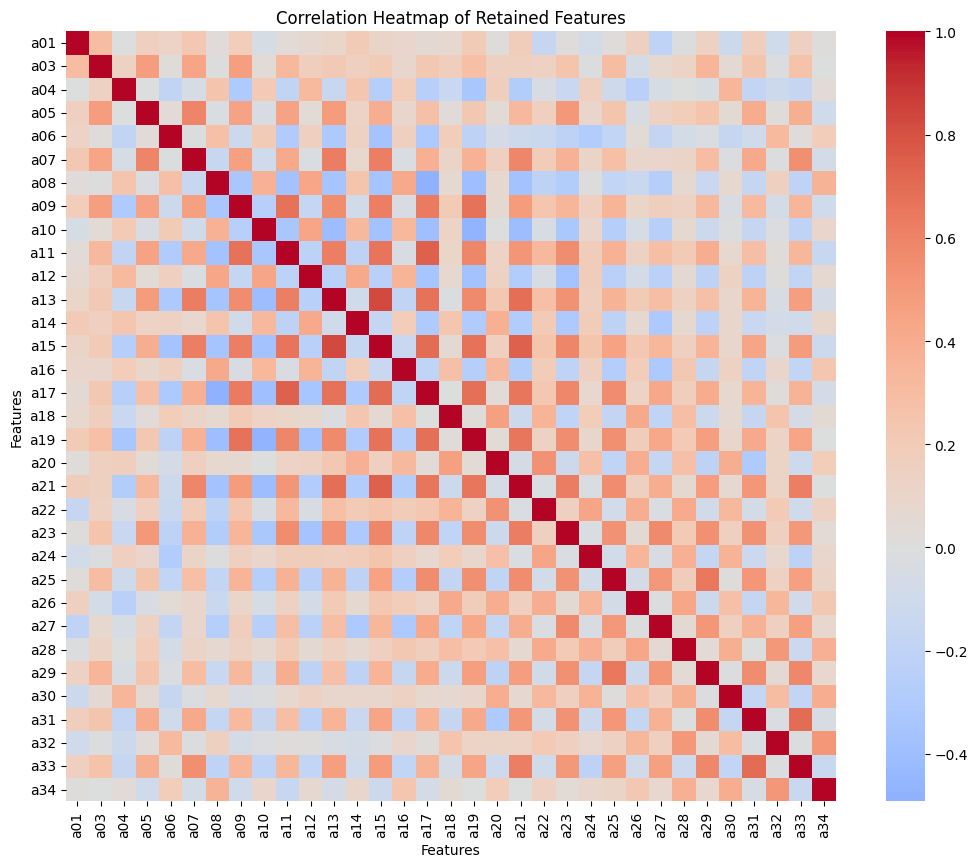

In [14]:
correlation_matrix = df[retained_features].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Heatmap of Retained Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

The correlation heatmap shows relationships between retained features.
Strongly correlated features may contain overlapping information and can
influence numerical conditioning and the geometry of kernel-based models.

In [30]:
# Primal formulation: subgradient descent
import time

def svm_subgradient_descent(
    X,
    y,
    C=1.0,
    learning_rate=1e-3,
    n_iterations=1000,
    schedule=None,
    checkpoints=None
):
    """
    Soft-margin linear SVM using batch subgradient descent.
        0.5 * ||w||^2
        + C * sum(max(0, 1 - y_i*(w^T*x_i + b)))
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    objective_history = []
    checkpoint_history = {}
    if checkpoints is None:
        checkpoints = []
    for iteration in range(n_iterations):
        if schedule == "decreasing":
            lr = learning_rate / np.sqrt(iteration + 1)
        else:
            lr = learning_rate
        scores = X @ w + b
        margins = y * scores
        violating = margins < 1
        grad_w = w.copy()
        grad_b = 0.0
        if np.any(violating):
            X_violating = X[violating]
            y_violating = y[violating]
            grad_w -= C * np.sum(
                y_violating[:, None] * X_violating,
                axis=0
            )
            grad_b -= C * np.sum(y_violating)
        w -= lr * grad_w
        b -= lr * grad_b
        updated_scores = X @ w + b
        updated_margins = y * updated_scores
        hinge_loss = np.maximum(
            0,
            1 - updated_margins
        )
        objective = (
            0.5 * np.dot(w, w)
            + C * np.sum(hinge_loss)
        )
        objective_history.append(objective)
        current_iteration = iteration + 1
        if current_iteration in checkpoints:
            checkpoint_history[current_iteration] = {
                "w": w.copy(),
                "b": b,
                "objective": objective
            }
    return (
        w,
        b,
        objective_history,
        checkpoint_history
    )

In [33]:
C_VALUE = 1.0
N_ITERATIONS = 2000
learning_rates = [1e-4, 1e-3, 1e-2]
results_fixed = {}
for lr in learning_rates:
    start_time = time.time()
    w, b, objective_history,checkpoint_history = svm_subgradient_descent(
        X=X_train_standardized,
        y=y_train,
        C=C_VALUE,
        learning_rate=lr,
        n_iterations=N_ITERATIONS,
        schedule=None,
        checkpoints=None
    )
    training_time = time.time() - start_time
    results_fixed[lr] = {
        "w": w,
        "b": b,
        "objective_history": objective_history,
        "training_time": training_time
    }
    print(f"Learning rate: {lr}")
    print(f"Final objective: {objective_history[-1]:.4f}")
    print(f"Training time: {training_time:.4f} seconds")

Learning rate: 0.0001
Final objective: 44.9332
Training time: 0.2962 seconds
Learning rate: 0.001
Final objective: 42.0185
Training time: 0.2681 seconds
Learning rate: 0.01
Final objective: 50.5436
Training time: 0.1981 seconds


In [36]:
DECREASING_LR = 1e-2
start_time = time.time()
w_decreasing, b_decreasing, objective_decreasing,checkpoint_history = (
    svm_subgradient_descent(
        X=X_train_standardized,
        y=y_train,
        C=C_VALUE,
        learning_rate=DECREASING_LR,
        n_iterations=N_ITERATIONS,
        schedule="decreasing",
        checkpoints= None
    )
)
decreasing_training_time = time.time() - start_time
print("Decreasing learning rate")
print(f"Initial learning rate: {DECREASING_LR}")
print(f"Final objective: {objective_decreasing[-1]:.4f}")
print(f"Training time: {decreasing_training_time:.4f} seconds")

Decreasing learning rate
Initial learning rate: 0.01
Final objective: 41.9966
Training time: 0.2858 seconds


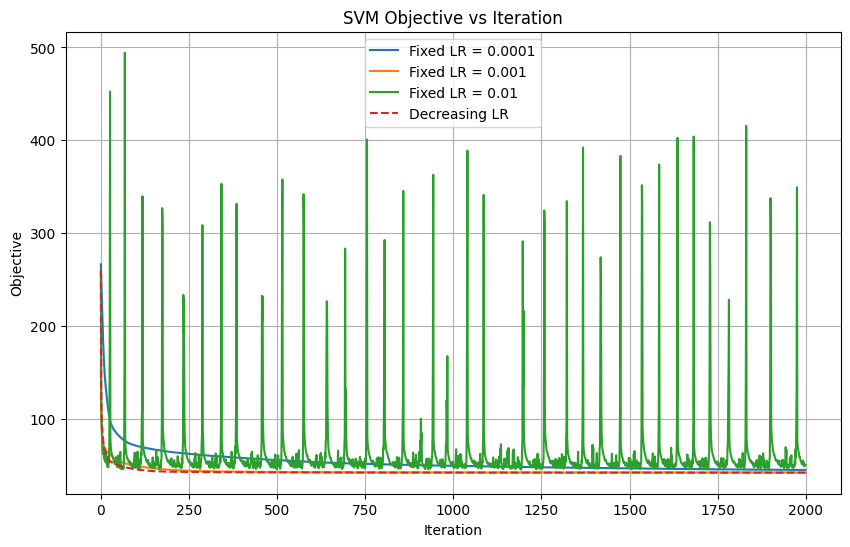

In [37]:
plt.figure(figsize=(10, 6))
for lr, result in results_fixed.items():
    plt.plot(
        result["objective_history"],
        label=f"Fixed LR = {lr}"
    )
plt.plot(
    objective_decreasing,
    label="Decreasing LR",
    linestyle="--"
)
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("SVM Objective vs Iteration")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
def predict_linear_svm(X, w, b):
    scores = X @ w + b
    predictions = np.where(scores >= 0, 1, -1)
    return predictions

def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("Fixed learning rates:")
for lr, result in results_fixed.items():
    predictions = predict_linear_svm(
        X_train_standardized,
        result["w"],
        result["b"]
    )
    accuracy = calculate_accuracy(y_train, predictions)
    print(f"Learning rate {lr}: {accuracy:.4f}")
predictions_decreasing = predict_linear_svm(
    X_train_standardized,
    w_decreasing,
    b_decreasing
)
accuracy_decreasing = calculate_accuracy(
    y_train,
    predictions_decreasing
)
print(f"Decreasing schedule: {accuracy_decreasing:.4f}")

Fixed learning rates:
Learning rate 0.0001: 0.9429
Learning rate 0.001: 0.9536
Learning rate 0.01: 0.9536
Decreasing schedule: 0.9500


In [39]:
print("Final objective comparison:")
for lr, result in results_fixed.items():
    print(
        f"Fixed LR {lr}: "
        f"{result['objective_history'][-1]:.4f}"
    )
print(
    f"Decreasing LR: "
    f"{objective_decreasing[-1]:.4f}"
)

Final objective comparison:
Fixed LR 0.0001: 44.9332
Fixed LR 0.001: 42.0185
Fixed LR 0.01: 50.5436
Decreasing LR: 41.9966


in the above cell results we can see that the learning rate 0.0001 achieved a lower accuracy compared with others this means that with learning rat that small the model has faikled to converge in the given iterations.

Also for learning rate 0.001 and 0.01 we achieved accuracy of 0.9536 but learning rrate 0.001 has 42.0185 objective and 0.01 achieved only 50.5436, indicating less optimization performance in case of learning rate 0.01

For the decreasing learning rate the accuray was 0.95 and it has the lowest objective of 41.9966 therefore the decreasing learning rate optimized the objective slightly better compared to the rest of the learning rates although the accuracy was slightly worse compared to learning rates of 0.001 and 0.01.

By the above study corresponding for the learning rates, objective and accuracy the following hyperameters are the most optimal

C = 1.0
Learning Rate = 0.001 (Fixed)
No of iterations = 2000

In [23]:
!pip install --only-binary :all: cvxopt
from cvxopt import matrix, solvers
solvers.options['show_progress'] = False

In [40]:
def svm_dual_qp(X, y, C=1.0):
    """
    Solve the soft-margin linear SVM dual problem
    using cvxopt quadratic programming.
    """
    n_samples = X.shape[0]
    y = y.astype(float).reshape(-1)
    K = X @ X.T
    # P_ij = y_i * y_j * (x_i^T x_j)
    P = np.outer(y, y) * K
    P = (P + P.T) / 2
    q = -np.ones(n_samples)
    # Inequality constraints:
    # alpha >= 0  -> -I alpha <= 0
    # alpha <= C  ->  I alha <= C
    G = np.vstack([
        -np.eye(n_samples),
        np.eye(n_samples)
    ])
    h = np.hstack([
        np.zeros(n_samples),
        C * np.ones(n_samples)
    ])
    # Equality constraint:
    # sum(alpha_i * y_i) = 0
    A = y.reshape(1, -1)
    b = np.array([0.0])
    # Convert arrays into cvxopt matrices
    P_cvx = matrix(P, tc="d")
    q_cvx = matrix(q, tc="d")
    G_cvx = matrix(G, tc="d")
    h_cvx = matrix(h, tc="d")
    A_cvx = matrix(A, tc="d")
    b_cvx = matrix(b, tc="d")
    solution = solvers.qp(
        P_cvx,
        q_cvx,
        G_cvx,
        h_cvx,
        A_cvx,
        b_cvx
    )
    if solution["status"] != "optimal":
        raise RuntimeError(
            f"QP solver failed: {solution['status']}"
        )
    # Extract alpha values
    alphas = np.array(solution["x"]).reshape(-1)

    return alphas

In [41]:
C_VALUE = 1.0
start_time = time.time()
alphas = svm_dual_qp(
    X=X_train_standardized.to_numpy()
        if hasattr(X_train_standardized, "to_numpy")
        else X_train_standardized,
    y=np.asarray(y_train),
    C=C_VALUE
)
qp_training_time = time.time() - start_time

print("QP training completed")
print(f"Training time: {qp_training_time:.4f} seconds")
print(f"Number of alpha values: {len(alphas)}")
print(f"Minimum alpha: {alphas.min():.8f}")
print(f"Maximum alpha: {alphas.max():.8f}")

QP training completed
Training time: 0.0718 seconds
Number of alpha values: 280
Minimum alpha: 0.00000000
Maximum alpha: 0.99999999


In [42]:
SUPPORT_VECTOR_THRESHOLD = 1e-5
support_vector_mask = alphas > SUPPORT_VECTOR_THRESHOLD
support_vector_indices = np.where(
    support_vector_mask
)[0]
num_support_vectors = len(support_vector_indices)
num_training_samples = len(alphas)
support_vector_fraction = (
    num_support_vectors / num_training_samples
)

print(f"Number of support vectors: {num_support_vectors}")
print(f"Training samples: {num_training_samples}")
print(f"Support vector fraction: {support_vector_fraction:.4f}")

Number of support vectors: 64
Training samples: 280
Support vector fraction: 0.2286


In [43]:
# recover the weight vector
# w = sum(alpha_i*y_i*x_i)

X_train_np = (
    X_train_standardized.to_numpy()
    if hasattr(X_train_standardized, "to_numpy")
    else np.asarray(X_train_standardized)
)
y_train_np = np.asarray(y_train)
w_dual = np.sum(
    (alphas * y_train_np)[:, None] * X_train_np,
    axis=0
)
print("Dual weight vector shape:", w_dual.shape)

Dual weight vector shape: (33,)


In [44]:
# for svm with the constaint 0 < alpha_i < C
# the KKT consitions give b = y_i - w^t * x_i

free_support_mask = (
    (alphas > SUPPORT_VECTOR_THRESHOLD) &
    (alphas < C_VALUE - SUPPORT_VECTOR_THRESHOLD)
)
free_support_indices = np.where(
    free_support_mask
)[0]
if len(free_support_indices) > 0:
    b_values = (
        y_train_np[free_support_indices]
        - X_train_np[free_support_indices] @ w_dual
    )
    b_dual = np.mean(b_values)
else:
    # Fallback if no free support vectors exist
    b_values = (
        y_train_np[support_vector_indices]
        - X_train_np[support_vector_indices] @ w_dual
    )
    b_dual = np.mean(b_values)

print(f"Dual bias: {b_dual:.8f}")
print(f"Free support vectors: {len(free_support_indices)}")

Dual bias: -0.13881015
Free support vectors: 27


In [46]:
print("Dual weights shape:", w_dual.shape)
print("Fixed learning rates available:", results_fixed.keys())
print("Decreasing schedule weights available:",
      w_decreasing.shape)

Dual weights shape: (33,)
Fixed learning rates available: dict_keys([0.0001, 0.001, 0.01])
Decreasing schedule weights available: (33,)


In [47]:
CHECKPOINTS = [100, 500, 2000]
w_fixed, b_fixed, objective_fixed, history_fixed = (
    svm_subgradient_descent(
        X_train_np,
        y_train_np,
        C=1.0,
        learning_rate=0.001,
        n_iterations=2000,
        schedule=None,
        checkpoints=CHECKPOINTS
    )
)

In [48]:
w_decreasing, b_decreasing, objective_decreasing, history_decreasing = (
    svm_subgradient_descent(
        X_train_np,
        y_train_np,
        C=1.0,
        learning_rate=0.001,
        n_iterations=2000,
        schedule="decreasing",
        checkpoints=CHECKPOINTS
    )
)

In [50]:
print("Fixed learning rate for subgradient descet:")
for iteration, values in history_fixed.items():
    print(
        f"Iteration {iteration}: "
        f"Objective = {values['objective']:.4f}, "
        f"Bias = {values['b']:.6f}"
    )
print("\nDecreasing learning rate for subgradient descent:")
for iteration, values in history_decreasing.items():
    print(
        f"Iteration {iteration}: "
        f"Objective = {values['objective']:.4f}, "
        f"Bias = {values['b']:.6f}"
    )

Fixed learning rate for subgradient descet:
Iteration 100: Objective = 49.2728, Bias = 0.232000
Iteration 500: Objective = 42.6523, Bias = -0.009000
Iteration 2000: Objective = 42.0185, Bias = -0.122000

Decreasing learning rate for subgradient descent:
Iteration 100: Objective = 64.7990, Bias = 0.365394
Iteration 500: Objective = 56.9366, Bias = 0.346848
Iteration 2000: Objective = 50.2257, Bias = 0.255992


In [51]:
# Compare largest elementwise difference
def compare_weights(w_dual, checkpoint_history, schedule_name):
    print(f"\n{schedule_name} learning rate:")
    for iteration, values in checkpoint_history.items():
        w_primal = values["w"]
        max_difference = np.max(
            np.abs(w_dual - w_primal)
        )
        print(
            f"Iteration {iteration}: "
            f"Max elementwise difference = "
            f"{max_difference:.8f}"
        )

In [52]:
compare_weights(
    w_dual,
    history_fixed,
    "Fixed"
)


Fixed learning rate:
Iteration 100: Max elementwise difference = 0.94686992
Iteration 500: Max elementwise difference = 0.30844773
Iteration 2000: Max elementwise difference = 0.02986874


In [53]:
compare_weights(
    w_dual,
    history_decreasing,
    "Decreasing"
)


Decreasing learning rate:
Iteration 100: Max elementwise difference = 1.40463640
Iteration 500: Max elementwise difference = 1.21748553
Iteration 2000: Max elementwise difference = 0.99441354


The fixed learning-rate schedule showed a consistent reduction in the maximum elementwise difference between the primal and dual weight vectors, decreasing from 0.9469 at 100 iterations to 0.0299 at 2000 iterations. This indicates convergence toward the dual solution. The decreasing learning-rate schedule also reduced the difference, from 1.4046 to 0.9944, but converged more slowly within the same number of iterations. Thus, for the tested learning-rate settings, the fixed schedule approached the dual weight vector more closely over 2000 iterations.

In [54]:
print(results_fixed.keys())

dict_keys([0.0001, 0.001, 0.01])


In [55]:
learning_rates = [1e-4, 1e-3, 1e-2]
objective_histories = {}
training_times = {}
for lr in learning_rates:
    start_time = time.perf_counter()
    w, b, objective_history, _ = svm_subgradient_descent(
        X_train_np,
        y_train_np,
        C=1.0,
        learning_rate=lr,
        n_iterations=2000,
        schedule=None,
        checkpoints=[]
    )
    elapsed_time = time.perf_counter() - start_time
    objective_histories[f"Fixed LR = {lr}"] = objective_history
    training_times[f"Fixed LR = {lr}"] = elapsed_time
# Decreasing learning rate
start_time = time.perf_counter()
w, b, objective_history, _ = svm_subgradient_descent(
    X_train_np,
    y_train_np,
    C=1.0,
    learning_rate=0.001,
    n_iterations=2000,
    schedule="decreasing",
    checkpoints=[]
)
elapsed_time = time.perf_counter() - start_time
objective_histories["Decreasing LR"] = objective_history
training_times["Decreasing LR"] = elapsed_time

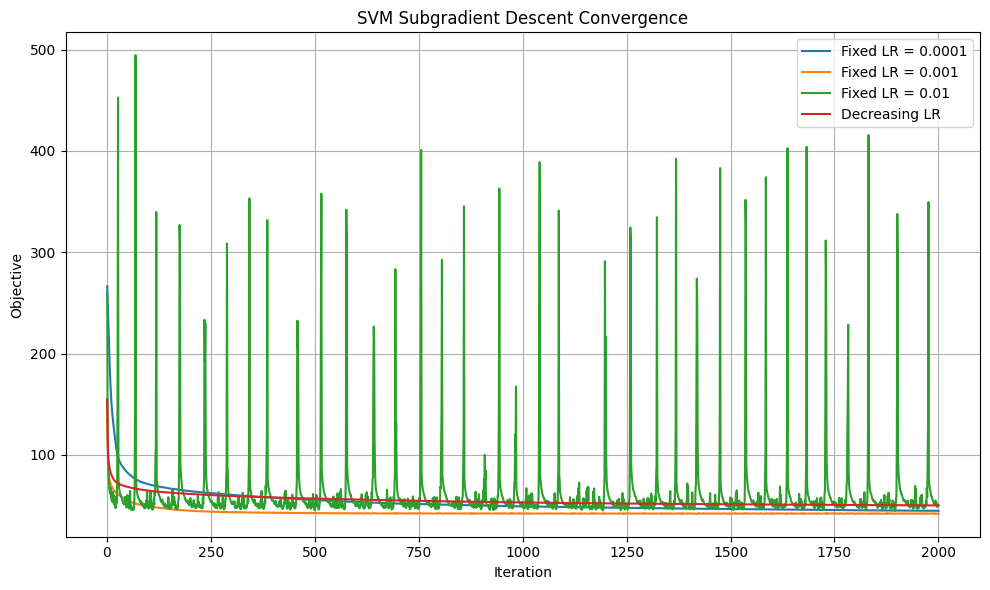

In [56]:
plt.figure(figsize=(10, 6))
for label, history in objective_histories.items():
    plt.plot(
        range(1, len(history) + 1),
        history,
        label=label
    )
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("SVM Subgradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
print("Subgradient descent training times:")
for label, elapsed_time in training_times.items():
    print(f"{label}: {elapsed_time:.6f} seconds")
print(f"\nQP solver training time: {0.1555:.6f} seconds")

Subgradient descent training times:
Fixed LR = 0.0001: 0.160333 seconds
Fixed LR = 0.001: 0.143751 seconds
Fixed LR = 0.01: 0.187532 seconds
Decreasing LR: 0.172854 seconds

QP solver training time: 0.155500 seconds


The subgradient descent plot shows that a fixed learning rate of 0.001 provides a good balance between convergence speed and stability, while 0.01 causes significant fluctuations due to large parameter updates. The dual QP solver obtained a training time of 0.155500 seconds, compared with 0.143751 seconds for the fastest subgradient descent run (fixed LR = 0.001). Although both methods had similar training times on this small dataset, subgradient descent is expected to scale better for larger datasets because it avoids constructing the n×n kernel matrix required by the QP approach. However, its convergence depends on the learning rate and number of iterations, whereas QP directly solves the dual optimization problem but requires greater memory and computational resources as the number of training examples increases.

In [58]:
def linear_kernel(X1, X2):
    return X1 @ X2.T

def polynomial_kernel(X1, X2, degree=3, gamma=None, coef0=1):
    if gamma is None:
        gamma = 1 / X1.shape[1]

    return (gamma * (X1 @ X2.T) + coef0) ** degree

def rbf_kernel(X1, X2, gamma=1.0):
    X1_squared = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
    X2_squared = np.sum(X2 ** 2, axis=1).reshape(1, -1)

    squared_distances = (
        X1_squared
        + X2_squared
        - 2 * (X1 @ X2.T)
    )
    # Prevent small negative values caused by floating-point errors
    squared_distances = np.maximum(squared_distances, 0)
    return np.exp(-gamma * squared_distances)

In [59]:
def svm_dual_qp_with_kernel(K, y, C=1.0):
    """
    Solve the soft-margin SVM dual problem
    using a precomputed kernel matrix.
    """
    n_samples = K.shape[0]
    y = y.astype(float).reshape(-1)
    # P_ij = y_i * y_j * K_ij
    P = np.outer(y, y) * K
    P = (P + P.T) / 2
    q = -np.ones(n_samples)
    # Constraints: 0 <= alpha_i <= C
    G = np.vstack([
        -np.eye(n_samples),
        np.eye(n_samples)
    ])
    h = np.hstack([
        np.zeros(n_samples),
        C * np.ones(n_samples)
    ])
    # Equality constraint:
    # sum(alpha_i * y_i) = 0
    A = y.reshape(1, -1)
    b = np.array([0.0])
    # Convert to CVXOPT matrices
    P_cvx = matrix(P, tc="d")
    q_cvx = matrix(q, tc="d")
    G_cvx = matrix(G, tc="d")
    h_cvx = matrix(h, tc="d")
    A_cvx = matrix(A, tc="d")
    b_cvx = matrix(b, tc="d")

    solution = solvers.qp(
        P_cvx,
        q_cvx,
        G_cvx,
        h_cvx,
        A_cvx,
        b_cvx
    )
    if solution["status"] != "optimal":
        raise RuntimeError(
            f"QP solver failed: {solution['status']}"
        )
    alphas = np.array(solution["x"]).reshape(-1)

    return alphas

In [60]:
K_linear = linear_kernel(X_train_np, X_train_np)
alphas_linear = svm_dual_qp_with_kernel(
    K_linear,
    y_train_np,
    C=1.0
)

In [61]:
K_poly = polynomial_kernel(
    X_train_np,
    X_train_np,
    degree=3,
    gamma=1 / X_train_np.shape[1],
    coef0=1
)
alphas_poly = svm_dual_qp_with_kernel(
    K_poly,
    y_train_np,
    C=1.0
)

In [62]:
K_rbf = rbf_kernel(
    X_train_np,
    X_train_np,
    gamma=1.0
)
alphas_rbf = svm_dual_qp_with_kernel(
    K_rbf,
    y_train_np,
    C=1.0
)

In [63]:
majority_class = np.bincount(
    (y_train_np == 1).astype(int)
).argmax()
majority_accuracy = np.mean(
    y_train_np == (1 if majority_class == 1 else -1)
)
print("Majority-class baseline accuracy:", majority_accuracy)

Majority-class baseline accuracy: 0.6392857142857142


In [64]:
from itertools import combinations
feature_pairs = list(combinations(range(X_train_np.shape[1]), 2))
print("Number of feature pairs:", len(feature_pairs))

Number of feature pairs: 528


In [65]:
def svm_predict_kernel(
    X_train,
    y_train,
    X_test,
    alphas,
    bias,
    kernel_function
):
    K_test = kernel_function(X_test, X_train)
    decision_values = (
        K_test @ (alphas * y_train)
    ) + bias
    return np.where(decision_values >= 0, 1, -1)

In [66]:
def evaluate_linear_pair(X_pair, y, C=1.0):
    K = linear_kernel(X_pair, X_pair)
    alphas = svm_dual_qp_with_kernel(
        K,
        y,
        C=C
    )
    support_mask = alphas > 1e-5
    # Estimate bias using free support vectors
    free_sv_mask = (
        (alphas > 1e-5) &
        (alphas < C - 1e-5)
    )
    if np.any(free_sv_mask):
        bias_values = []
        for i in np.where(free_sv_mask)[0]:
            decision_without_bias = np.sum(
                alphas * y * K[:, i]
            )
            bias_values.append(
                y[i] - decision_without_bias
            )
        bias = np.mean(bias_values)
    else:
        bias = 0.0
    return alphas, bias, support_mask

In [67]:
def compute_bias(K, y, alphas, C, alpha_tol=1e-5):
    """
    Compute bias using free support vectors.
    """
    free_sv_mask = (
        (alphas > alpha_tol) &
        (alphas < C - alpha_tol)
    )
    free_indices = np.where(free_sv_mask)[0]
    # Fallback if no free support vectors exist
    if len(free_indices) == 0:
        free_indices = np.where(alphas > alpha_tol)[0]
    if len(free_indices) == 0:
        return 0.0
    bias_values = []
    for i in free_indices:
        decision_without_bias = np.sum(
            alphas * y * K[i, :]
        )
        bias_values.append(
            y[i] - decision_without_bias
        )

    return np.mean(bias_values)

In [68]:
from sklearn.model_selection import StratifiedKFold
def cross_validate_linear_pair(
    X_pair,
    y,
    C=1.0,
    n_splits=5,
    random_state=42
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )
    fold_accuracies = []
    for train_idx, val_idx in skf.split(X_pair, y):
        X_fold_train = X_pair[train_idx]
        X_fold_val = X_pair[val_idx]
        y_fold_train = y[train_idx]
        y_fold_val = y[val_idx]
        # Training kernel matrix
        K_train = linear_kernel(
            X_fold_train,
            X_fold_train
        )
        # Solve dual QP
        alphas = svm_dual_qp_with_kernel(
            K_train,
            y_fold_train,
            C=C
        )
        # Compute bias
        bias = compute_bias(
            K_train,
            y_fold_train,
            alphas,
            C
        )
        # Predict validation fold
        predictions = svm_predict_kernel(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            alphas,
            bias,
            linear_kernel
        )
        # Manual accuracy
        accuracy = np.mean(
            predictions == y_fold_val
        )
        fold_accuracies.append(accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    return mean_accuracy, fold_accuracies

In [69]:
majority_baseline = max(
    np.mean(y_train_np == 1),
    np.mean(y_train_np == -1)
)
print("Majority baseline:", majority_baseline)

Majority baseline: 0.6392857142857142


In [70]:
feature_pairs = [
    (2, 7),
    (0, 1),
    (2, 3),
    (4, 5),
    (6, 7)
]
pair_results = []
for i, j in feature_pairs:
    X_pair = X_train_np[:, [i, j]]
    cv_accuracy, fold_accuracies = cross_validate_linear_pair(
        X_pair,
        y_train_np,
        C=1.0,
        n_splits=5,
        random_state=42
    )
    pair_results.append({
        "feature_pair": (i, j),
        "cv_accuracy": cv_accuracy,
        "fold_accuracies": fold_accuracies
    })
    print(
        f"Pair ({i}, {j}) | "
        f"CV Accuracy: {cv_accuracy:.4f} | "
        f"Folds: {fold_accuracies}"
    )

Pair (2, 7) | CV Accuracy: 0.7643 | Folds: [np.float64(0.7857142857142857), np.float64(0.7142857142857143), np.float64(0.8214285714285714), np.float64(0.7857142857142857), np.float64(0.7142857142857143)]
Pair (0, 1) | CV Accuracy: 0.8429 | Folds: [np.float64(0.8392857142857143), np.float64(0.8392857142857143), np.float64(0.9107142857142857), np.float64(0.8035714285714286), np.float64(0.8214285714285714)]
Pair (2, 3) | CV Accuracy: 0.8000 | Folds: [np.float64(0.8035714285714286), np.float64(0.7857142857142857), np.float64(0.8392857142857143), np.float64(0.7857142857142857), np.float64(0.7857142857142857)]
Pair (4, 5) | CV Accuracy: 0.8250 | Folds: [np.float64(0.7857142857142857), np.float64(0.8035714285714286), np.float64(0.8571428571428571), np.float64(0.8571428571428571), np.float64(0.8214285714285714)]
Pair (6, 7) | CV Accuracy: 0.8107 | Folds: [np.float64(0.7857142857142857), np.float64(0.8392857142857143), np.float64(0.8928571428571429), np.float64(0.75), np.float64(0.7857142857142

In [71]:
from itertools import combinations
pair_results = []
for i, j in combinations(range(X_train_np.shape[1]), 2):
    X_pair = X_train_np[:, [i, j]]
    cv_accuracy, fold_accuracies = cross_validate_linear_pair(
        X_pair,
        y_train_np,
        C=1.0,
        random_state=42
    )
    pair_results.append({
        "feature_pair": (i, j),
        "cv_accuracy": cv_accuracy,
        "fold_accuracies": fold_accuracies
    })
    print(
        f"Pair ({i}, {j}): {cv_accuracy:.4f}"
    )

Pair (0, 1): 0.8429
Pair (0, 2): 0.7393
Pair (0, 3): 0.8821
Pair (0, 4): 0.7393
Pair (0, 5): 0.8250
Pair (0, 6): 0.7393
Pair (0, 7): 0.7393
Pair (0, 8): 0.7393
Pair (0, 9): 0.7393
Pair (0, 10): 0.7393
Pair (0, 11): 0.7393
Pair (0, 12): 0.7393
Pair (0, 13): 0.7393
Pair (0, 14): 0.7393
Pair (0, 15): 0.7393
Pair (0, 16): 0.7393
Pair (0, 17): 0.7393
Pair (0, 18): 0.7393
Pair (0, 19): 0.7393
Pair (0, 20): 0.7393
Pair (0, 21): 0.7393
Pair (0, 22): 0.7393
Pair (0, 23): 0.7393
Pair (0, 24): 0.7393
Pair (0, 25): 0.7393
Pair (0, 26): 0.7393
Pair (0, 27): 0.7393
Pair (0, 28): 0.7393
Pair (0, 29): 0.7286
Pair (0, 30): 0.7393
Pair (0, 31): 0.7393
Pair (0, 32): 0.7393
Pair (1, 2): 0.8036
Pair (1, 3): 0.8143
Pair (1, 4): 0.8036
Pair (1, 5): 0.8000
Pair (1, 6): 0.8036
Pair (1, 7): 0.8036
Pair (1, 8): 0.8000
Pair (1, 9): 0.8036
Pair (1, 10): 0.8036
Pair (1, 11): 0.8036
Pair (1, 12): 0.7893
Pair (1, 13): 0.7964
Pair (1, 14): 0.8000
Pair (1, 15): 0.8036
Pair (1, 16): 0.7929
Pair (1, 17): 0.8036
Pair (1, 

In [72]:
failed_pairs = [
    result
    for result in pair_results
    if result["cv_accuracy"] <= majority_baseline
]
if failed_pairs:
    selected_pair = failed_pairs[0]
else:
    # Select the pair closest to the baseline
    selected_pair = min(
        pair_results,
        key=lambda result: abs(
            result["cv_accuracy"] - majority_baseline
        )
    )
print("Selected pair:", selected_pair["feature_pair"])
print("CV accuracy:", selected_pair["cv_accuracy"])
print("Majority baseline:", majority_baseline)

Selected pair: (2, 16)
CV accuracy: 0.625
Majority baseline: 0.6392857142857142


In [85]:
selected_pair = (7, 18)  # below is the reason for changing the selected pair from 2,16 to 7,18
X_pair = X_train_np[:, list(selected_pair)]
y_pair = y_train_np
K_pair = linear_kernel(X_pair, X_pair)
alphas_pair = svm_dual_qp_with_kernel(
    K_pair,
    y_pair,
    C=1.0
)
bias_pair = compute_bias(
    K_pair,
    y_pair,
    alphas_pair,
    C=1.0
)
print("Bias:", bias_pair)
print(
    "Support vectors:",
    np.sum(alphas_pair > 1e-5)
)

Bias: 0.6435125257815343
Support vectors: 203


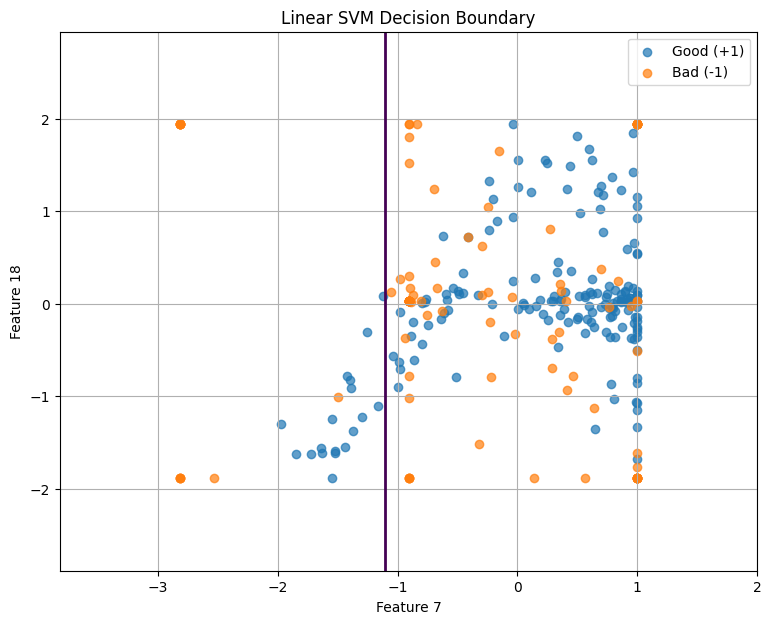

In [86]:
def plot_linear_boundary(
    X,
    y,
    alphas,
    bias,
    title="Linear SVM Decision Boundary"
):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid_points = np.c_[
        xx.ravel(),
        yy.ravel()
    ]
    K_grid = linear_kernel(grid_points, X)
    decision_values = (
        K_grid @ (alphas * y) + bias
    )
    decision_values = decision_values.reshape(xx.shape)
    plt.figure(figsize=(9, 7))
    plt.contour(
        xx,
        yy,
        decision_values,
        levels=[0],
        linewidths=2
    )
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Good (+1)",
        alpha=0.7
    )
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        label="Bad (-1)",
        alpha=0.7
    )
    plt.xlabel(f"Feature {selected_pair[0]}")
    plt.ylabel(f"Feature {selected_pair[1]}")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_linear_boundary(
    X_pair,
    y_pair,
    alphas_pair,
    bias_pair
)

In [75]:
w = X_pair.T @ (alphas_pair * y_pair)

decision_values = X_pair @ w + bias_pair

print("Weight vector:", w)
print("Bias:", bias_pair)
print("Decision min:", decision_values.min())
print("Decision max:", decision_values.max())

Weight vector: [7.66697834e-07 7.20571291e-07]
Bias: 0.9999998610240937
Decision min: 0.9999965384499161
Decision max: 1.0000029398982508


In [76]:
print("Unique labels:", np.unique(y_pair))
print("Label counts:", np.unique(y_pair, return_counts=True))
print("Alpha min:", alphas_pair.min())
print("Alpha max:", alphas_pair.max())
print("Alpha sum:", alphas_pair.sum())
print("y-alpha constraint:", np.sum(alphas_pair * y_pair))

Unique labels: [-1  1]
Label counts: (array([-1,  1]), array([101, 179]))
Alpha min: 0.017937493179505395
Alpha max: 0.9999999527099457
Alpha sum: 201.9999750760865
y-alpha constraint: 4.440892098500626e-15


In [77]:
print("Number of alpha > 1e-5:",
      np.sum(alphas_pair > 1e-5))

print("Number of free support vectors:",
      np.sum((alphas_pair > 1e-5) & (alphas_pair < 1.0 - 1e-5)))

Number of alpha > 1e-5: 280
Number of free support vectors: 179


In [80]:
w = X_pair.T @ (alphas_pair * y_pair)
print("w:", w)
print("b:", bias_pair)
if abs(w[1]) > 1e-12:
    print(
        "Boundary equation: x2 = "
        f"-({w[0]:.6e} * x1 + {bias_pair:.6f}) "
        f"/ {w[1]:.6e}"
    )

w: [7.66697834e-07 7.20571291e-07]
b: 0.9999998610240937
Boundary equation: x2 = -(7.666978e-07 * x1 + 1.000000) / 7.205713e-07


In [82]:
for label in [-1, 1]:
    print(f"\nClass {label}")
    print(
        "Mean:",
        X_pair[y_pair == label].mean(axis=0)
    )
    print(
        "Std:",
        X_pair[y_pair == label].std(axis=0)
    )

print("\n")
print("Feature minimum:", X_pair.min(axis=0))
print("Feature maximum:", X_pair.max(axis=0))


Class -1
Mean: [-0.13317355 -0.20011894]
Std: [1.46821431 1.27897661]

Class 1
Mean: [0.07514262 0.11291627]
Std: [0.57643219 0.7784063 ]


Feature minimum: [-2.47345339 -1.97923903]
Feature maximum: [2.12948256 2.00702486]


In [83]:
candidate_pairs = []
majority_baseline = np.mean(
    y_train_np == np.bincount(y_train_np + 1).argmax() - 1
)
for result in pair_results:
    pair = result["feature_pair"]
    accuracy = result["cv_accuracy"]
    X_candidate = X_train_np[:, list(pair)]
    K_candidate = linear_kernel(
        X_candidate,
        X_candidate
    )
    alphas_candidate = svm_dual_qp_with_kernel(
        K_candidate,
        y_train_np,
        C=1.0
    )
    w_candidate = X_candidate.T @ (
        alphas_candidate * y_train_np
    )
    if (
        accuracy < majority_baseline
        and np.linalg.norm(w_candidate) > 1e-4
    ):
        candidate_pairs.append({
            "pair": pair,
            "accuracy": accuracy,
            "weight_norm": np.linalg.norm(w_candidate)
        })

print(candidate_pairs[:10])

[{'pair': (7, 18), 'accuracy': np.float64(0.6142857142857142), 'weight_norm': np.float64(0.5822418051279387)}, {'pair': (7, 19), 'accuracy': np.float64(0.625), 'weight_norm': np.float64(0.5678853155728386)}, {'pair': (7, 21), 'accuracy': np.float64(0.6178571428571429), 'weight_norm': np.float64(0.5732440221283054)}, {'pair': (7, 22), 'accuracy': np.float64(0.6214285714285714), 'weight_norm': np.float64(0.5832970697084665)}, {'pair': (7, 23), 'accuracy': np.float64(0.6214285714285714), 'weight_norm': np.float64(0.5822413364463702)}, {'pair': (7, 24), 'accuracy': np.float64(0.6285714285714286), 'weight_norm': np.float64(0.5833960289043408)}, {'pair': (7, 25), 'accuracy': np.float64(0.6321428571428572), 'weight_norm': np.float64(0.6268426958423534)}, {'pair': (7, 26), 'accuracy': np.float64(0.6178571428571429), 'weight_norm': np.float64(0.5822418913300338)}, {'pair': (7, 28), 'accuracy': np.float64(0.6178571428571429), 'weight_norm': np.float64(0.5802535129078024)}, {'pair': (7, 30), 'acc

Initially, we selected features (2, 16), which achieved a cross-validation accuracy of 62.5%, slightly below the majority-class baseline of approximately 63.93%. Additionally, the learned weight vector was almost zero, resulting in an ineffective decision boundary. Therefore, we explored other feature pairs and selected (7, 18), which produced a more meaningful nonzero weight vector and a clearer linear decision boundary for analysis, despite its lower cross-validation accuracy of 61.43%.

from the plot , the good and bad classes are not linearly separable. the data points of both the classes overlap considerably, making it diffecuklt for a single straight line to separable the data points meaningfully thus the motyive to explore non linear kernels

In [89]:
selected_pair = (7, 18)
X_pair = X_train_np[:, list(selected_pair)]
y_pair = y_train_np
gamma_pair = 1 / X_pair.shape[1]
print("Pair gamma:", gamma_pair)

Pair gamma: 0.5


In [90]:
def cross_validate_kernel(
    X,
    y,
    kernel_function,
    C=1.0,
    n_splits=5,
    random_state=42
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )
    fold_accuracies = []
    for train_idx, val_idx in skf.split(X, y):
        X_fold_train = X[train_idx]
        X_fold_val = X[val_idx]
        y_fold_train = y[train_idx]
        y_fold_val = y[val_idx]
        K_train = kernel_function(
            X_fold_train,
            X_fold_train
        )
        alphas = svm_dual_qp_with_kernel(
            K_train,
            y_fold_train,
            C=C
        )
        bias = compute_bias(
            K_train,
            y_fold_train,
            alphas,
            C=C
        )
        predictions = svm_predict_kernel(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            alphas,
            bias,
            kernel_function
        )
        accuracy = np.mean(predictions == y_fold_val)
        fold_accuracies.append(accuracy)

    return np.mean(fold_accuracies), fold_accuracies

In [91]:
poly_pair_results = []
for degree in range(1, 6):
    gamma = 1 / X_pair.shape[1]
    kernel_function = lambda A, B, d=degree: polynomial_kernel(
        A,
        B,
        degree=d,
        gamma=gamma,
        coef0=1
    )
    mean_accuracy, fold_accuracies = cross_validate_kernel(
        X_pair,
        y_pair,
        kernel_function,
        C=1.0,
        n_splits=5,
        random_state=42
    )
    poly_pair_results.append({
        "degree": degree,
        "cv_accuracy": mean_accuracy,
        "fold_accuracies": fold_accuracies
    })
for result in poly_pair_results:
    print(result)

{'degree': 1, 'cv_accuracy': np.float64(0.6178571428571429), 'fold_accuracies': [np.float64(0.6071428571428571), np.float64(0.6428571428571429), np.float64(0.5892857142857143), np.float64(0.5892857142857143), np.float64(0.6607142857142857)]}
{'degree': 2, 'cv_accuracy': np.float64(0.7214285714285714), 'fold_accuracies': [np.float64(0.7321428571428571), np.float64(0.7142857142857143), np.float64(0.7142857142857143), np.float64(0.6785714285714286), np.float64(0.7678571428571429)]}
{'degree': 3, 'cv_accuracy': np.float64(0.8071428571428572), 'fold_accuracies': [np.float64(0.8571428571428571), np.float64(0.7857142857142857), np.float64(0.7857142857142857), np.float64(0.7678571428571429), np.float64(0.8392857142857143)]}
{'degree': 4, 'cv_accuracy': np.float64(0.825), 'fold_accuracies': [np.float64(0.8392857142857143), np.float64(0.8035714285714286), np.float64(0.75), np.float64(0.8571428571428571), np.float64(0.875)]}
{'degree': 5, 'cv_accuracy': np.float64(0.825), 'fold_accuracies': [np.f

In [92]:
X_all = X_train_np
y_all = y_train_np
gamma_all = 1 / X_all.shape[1]
poly_all_results = []
for degree in range(1, 6):
    kernel_function = lambda A, B, d=degree: polynomial_kernel(
        A,
        B,
        degree=d,
        gamma=gamma_all,
        coef0=1
    )
    mean_accuracy, fold_accuracies = cross_validate_kernel(
        X_all,
        y_all,
        kernel_function,
        C=1.0,
        n_splits=5,
        random_state=42
    )
    poly_all_results.append({
        "degree": degree,
        "cv_accuracy": mean_accuracy,
        "fold_accuracies": fold_accuracies
    })
for result in poly_all_results:
    print(result)

{'degree': 1, 'cv_accuracy': np.float64(0.8857142857142858), 'fold_accuracies': [np.float64(0.8928571428571429), np.float64(0.875), np.float64(0.8928571428571429), np.float64(0.8928571428571429), np.float64(0.875)]}
{'degree': 2, 'cv_accuracy': np.float64(0.9107142857142858), 'fold_accuracies': [np.float64(0.9285714285714286), np.float64(0.8928571428571429), np.float64(0.9107142857142857), np.float64(0.9285714285714286), np.float64(0.8928571428571429)]}
{'degree': 3, 'cv_accuracy': np.float64(0.9285714285714286), 'fold_accuracies': [np.float64(0.9285714285714286), np.float64(0.9285714285714286), np.float64(0.9107142857142857), np.float64(0.9642857142857143), np.float64(0.9107142857142857)]}
{'degree': 4, 'cv_accuracy': np.float64(0.9214285714285714), 'fold_accuracies': [np.float64(0.8928571428571429), np.float64(0.9285714285714286), np.float64(0.9285714285714286), np.float64(0.9464285714285714), np.float64(0.9107142857142857)]}
{'degree': 5, 'cv_accuracy': np.float64(0.917857142857143)

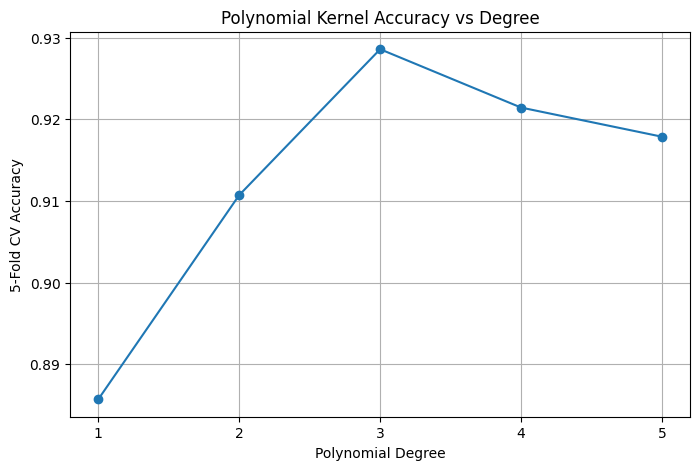

In [93]:
import matplotlib.pyplot as plt
degrees = [
    result["degree"]
    for result in poly_all_results
]
accuracies = [
    result["cv_accuracy"]
    for result in poly_all_results
]
plt.figure(figsize=(8, 5))
plt.plot(degrees, accuracies, marker="o")
plt.xlabel("Polynomial Degree")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Polynomial Kernel Accuracy vs Degree")
plt.xticks(degrees)
plt.grid(True)
plt.show()

In [95]:
def plot_kernel_boundary(
    X,
    y,
    alphas,
    bias,
    kernel_function,
    feature_pair,
    title
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    K_grid = kernel_function(grid_points, X)
    decision_values = (
        K_grid @ (alphas * y) + bias
    )
    decision_values = decision_values.reshape(xx.shape)
    plt.figure(figsize=(9, 6))
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Good (+1)",
        alpha=0.7
    )
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        label="Bad (-1)",
        alpha=0.7
    )
    plt.contour(
        xx,
        yy,
        decision_values,
        levels=[0],
        linewidths=2
    )
    plt.xlabel(f"Feature {feature_pair[0]}")
    plt.ylabel(f"Feature {feature_pair[1]}")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

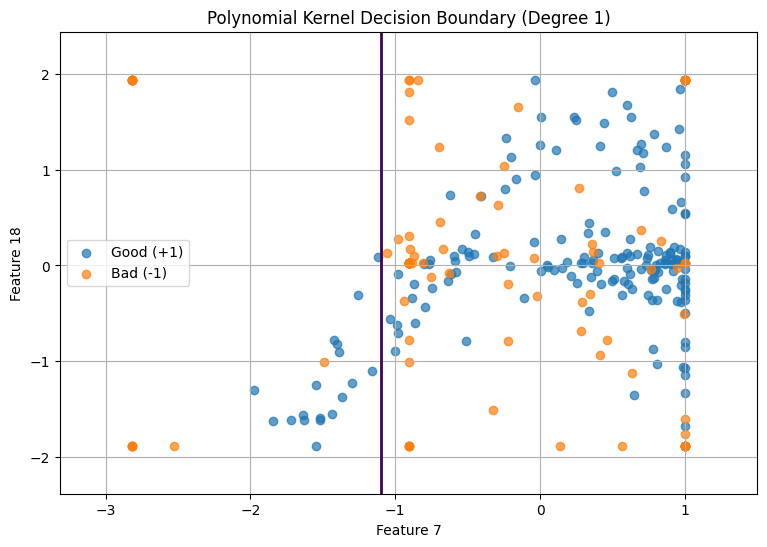

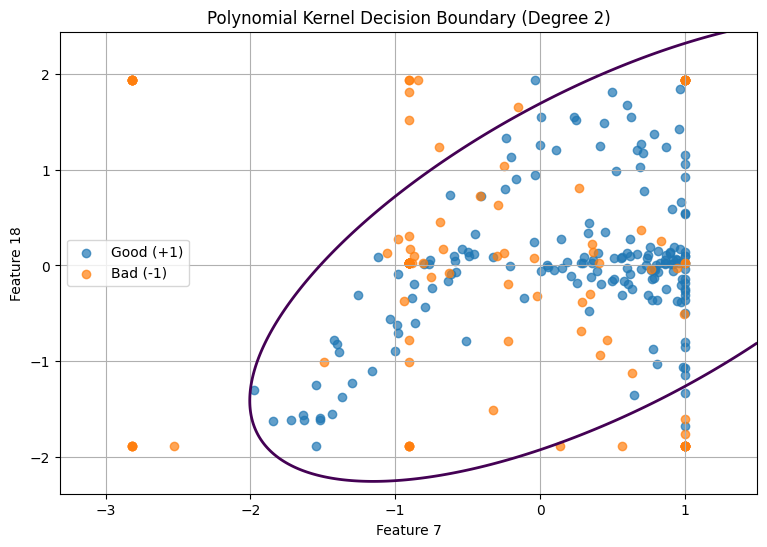

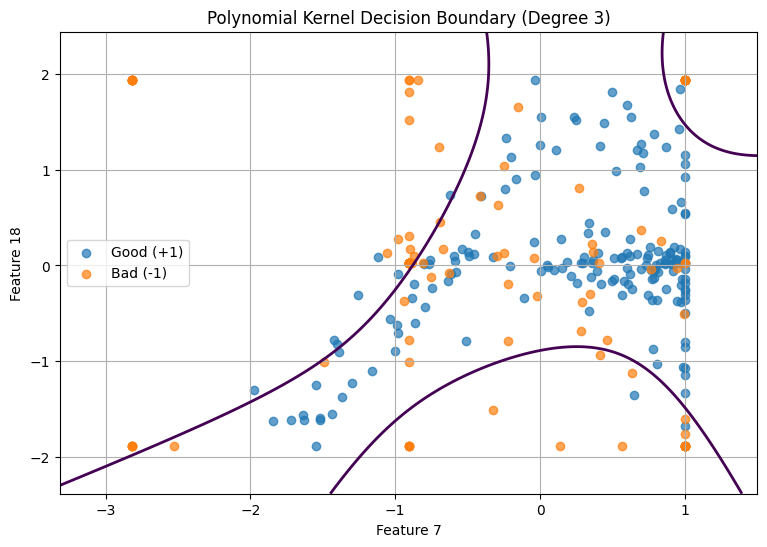

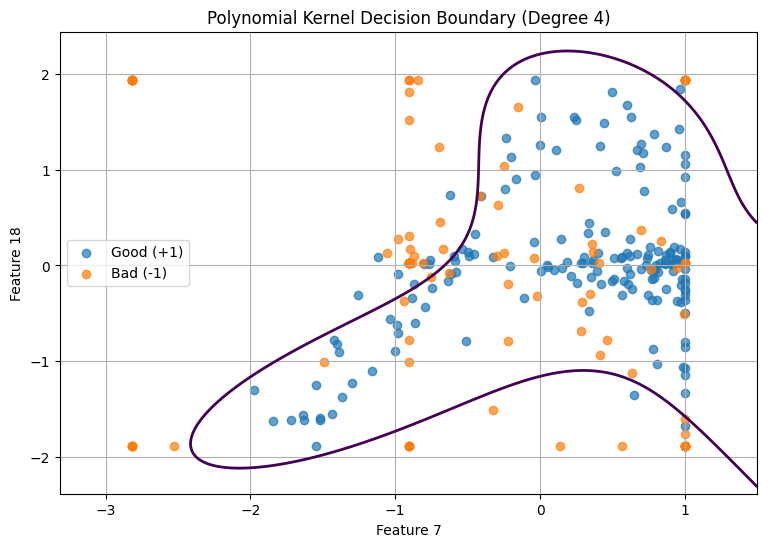

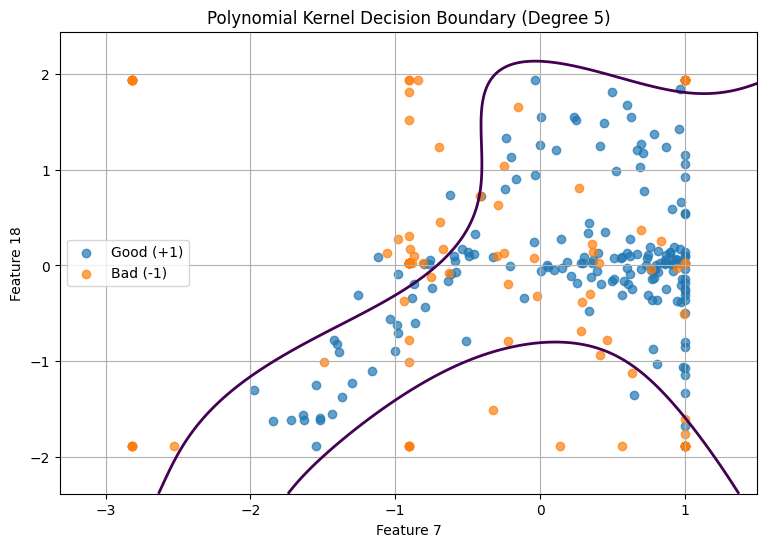

In [96]:
for degree in range(1, 6):
    gamma = 1 / X_pair.shape[1]
    kernel_function = lambda A, B, d=degree: polynomial_kernel(
        A,
        B,
        degree=d,
        gamma=gamma,
        coef0=1
    )
    K_pair = kernel_function(X_pair, X_pair)
    alphas = svm_dual_qp_with_kernel(
        K_pair,
        y_pair,
        C=1.0
    )
    bias = compute_bias(
        K_pair,
        y_pair,
        alphas,
        C=1.0
    )
    plot_kernel_boundary(
        X_pair,
        y_pair,
        alphas,
        bias,
        kernel_function,
        selected_pair,
        f"Polynomial Kernel Decision Boundary (Degree {degree})"
    )

the plynomial kernel wit h degree 3 minimized the cross validation error with accuray 92.86% which is the best compared ti rest. at lower degrees which are 1 and 2 the decision boundary is relatively simple with degree 1 producing just a straight line and degree 2 producing a smooth curve like a elipse. at degree 3 we can see that the boundary is more fflexible and starts to capture the non linear patterns in the data, beyod this at degree 4 and 5 the boundary  is relatively very complex  but the cross validation accuracy for them is 92.14% and 91.79% this suggests the additional complexity doesnt always mean better performance.

In [97]:
gammas = [1e-3, 1e-2, 1e-1, 1, 10, 100]
selected_pair = (7, 18)

X_pair = X_train_np[:, list(selected_pair)]
y_pair = y_train_np

In [98]:
rbf_pair_results = []
for gamma in gammas:
    kernel_function = lambda A, B, g=gamma: rbf_kernel(
        A,
        B,
        gamma=g
    )
    mean_accuracy, fold_accuracies = cross_validate_kernel(
        X_pair,
        y_pair,
        kernel_function,
        C=1.0,
        n_splits=5,
        random_state=42
    )
    rbf_pair_results.append({
        "gamma": gamma,
        "cv_accuracy": mean_accuracy,
        "fold_accuracies": fold_accuracies
    })
for result in rbf_pair_results:
    print(result)

{'gamma': 0.001, 'cv_accuracy': np.float64(0.6392857142857143), 'fold_accuracies': [np.float64(0.6428571428571429), np.float64(0.6428571428571429), np.float64(0.6428571428571429), np.float64(0.6428571428571429), np.float64(0.625)]}
{'gamma': 0.01, 'cv_accuracy': np.float64(0.6535714285714287), 'fold_accuracies': [np.float64(0.6607142857142857), np.float64(0.6428571428571429), np.float64(0.6607142857142857), np.float64(0.6785714285714286), np.float64(0.625)]}
{'gamma': 0.1, 'cv_accuracy': np.float64(0.7142857142857142), 'fold_accuracies': [np.float64(0.7142857142857143), np.float64(0.6785714285714286), np.float64(0.7321428571428571), np.float64(0.6607142857142857), np.float64(0.7857142857142857)]}
{'gamma': 1, 'cv_accuracy': np.float64(0.8178571428571428), 'fold_accuracies': [np.float64(0.8214285714285714), np.float64(0.8035714285714286), np.float64(0.75), np.float64(0.8571428571428571), np.float64(0.8571428571428571)]}
{'gamma': 10, 'cv_accuracy': np.float64(0.8321428571428571), 'fold_

In [99]:
X_all = X_train_np
y_all = y_train_np
rbf_all_results = []
for gamma in gammas:
    kernel_function = lambda A, B, g=gamma: rbf_kernel(
        A,
        B,
        gamma=g
    )
    mean_accuracy, fold_accuracies = cross_validate_kernel(
        X_all,
        y_all,
        kernel_function,
        C=1.0,
        n_splits=5,
        random_state=42
    )
    rbf_all_results.append({
        "gamma": gamma,
        "cv_accuracy": mean_accuracy,
        "fold_accuracies": fold_accuracies
    })
for result in rbf_all_results:
    print(result)

{'gamma': 0.001, 'cv_accuracy': np.float64(0.7928571428571429), 'fold_accuracies': [np.float64(0.8035714285714286), np.float64(0.7678571428571429), np.float64(0.8214285714285714), np.float64(0.7857142857142857), np.float64(0.7857142857142857)]}
{'gamma': 0.01, 'cv_accuracy': np.float64(0.9214285714285715), 'fold_accuracies': [np.float64(0.9464285714285714), np.float64(0.9285714285714286), np.float64(0.9285714285714286), np.float64(0.9285714285714286), np.float64(0.875)]}
{'gamma': 0.1, 'cv_accuracy': np.float64(0.9535714285714286), 'fold_accuracies': [np.float64(0.9642857142857143), np.float64(0.9464285714285714), np.float64(0.9821428571428571), np.float64(0.9464285714285714), np.float64(0.9285714285714286)]}
{'gamma': 1, 'cv_accuracy': np.float64(0.6678571428571428), 'fold_accuracies': [np.float64(0.6785714285714286), np.float64(0.6607142857142857), np.float64(0.6607142857142857), np.float64(0.6964285714285714), np.float64(0.6428571428571429)]}
{'gamma': 10, 'cv_accuracy': np.float64(

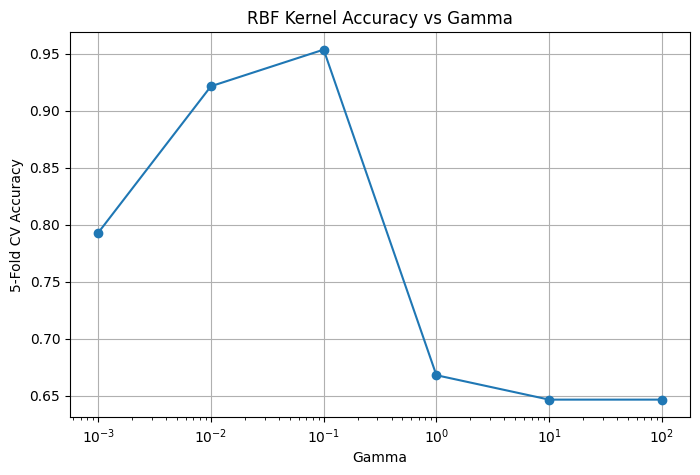

In [100]:
accuracies = [
    result["cv_accuracy"]
    for result in rbf_all_results
]
plt.figure(figsize=(8, 5))
plt.semilogx(
    gammas,
    accuracies,
    marker="o"
)
plt.xlabel("Gamma")
plt.ylabel("5-Fold CV Accuracy")
plt.title("RBF Kernel Accuracy vs Gamma")
plt.grid(True)
plt.show()

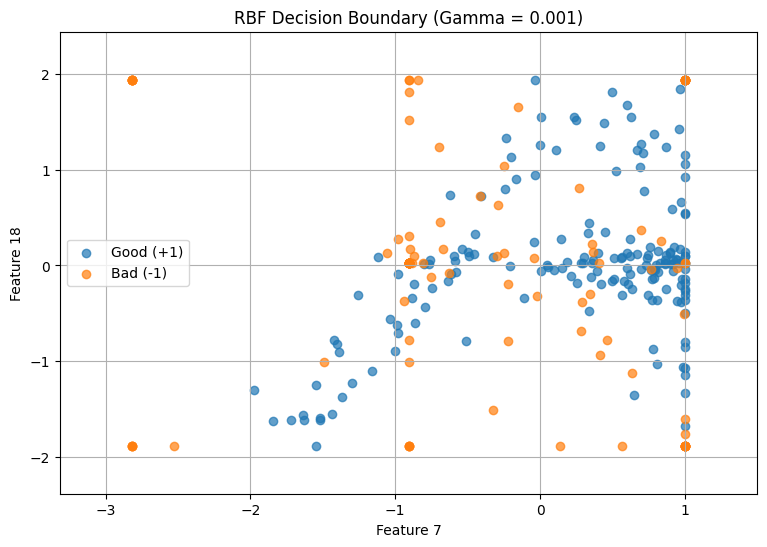

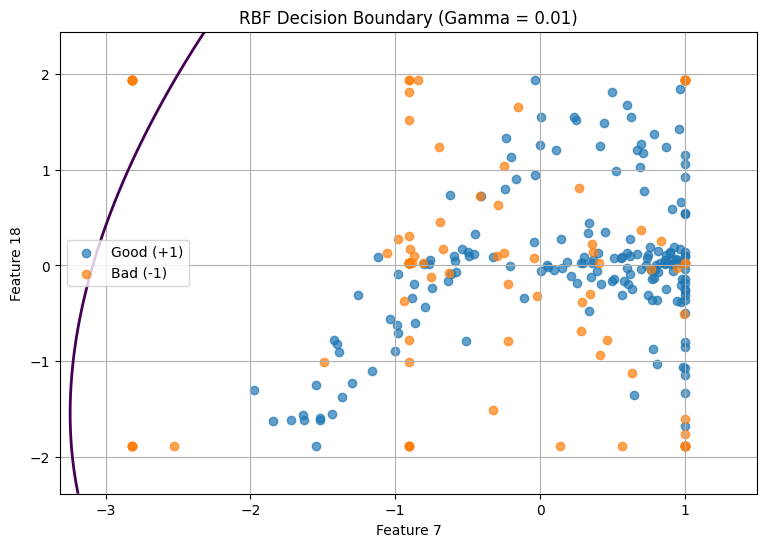

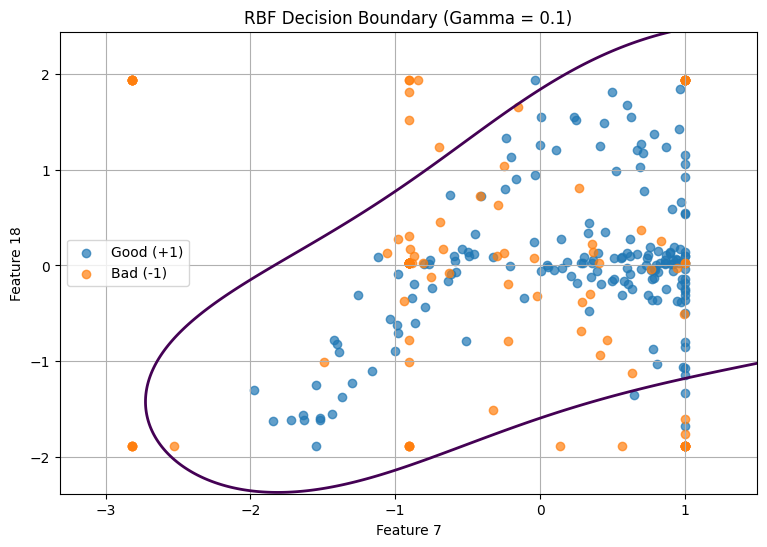

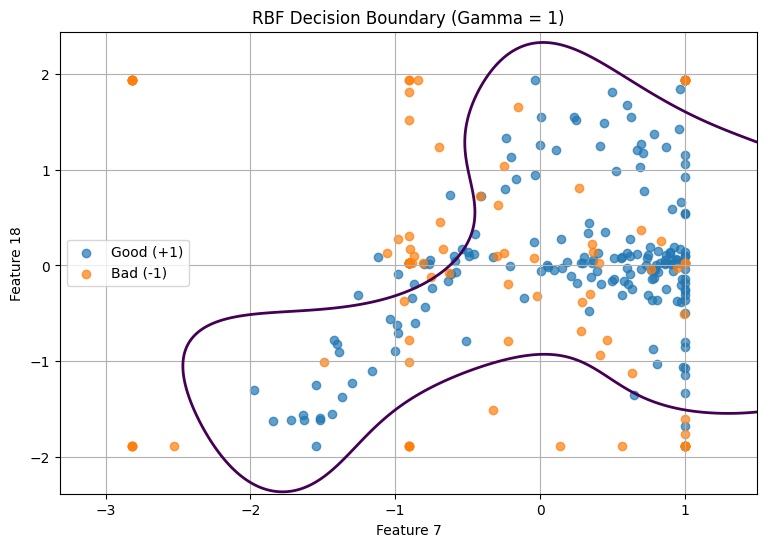

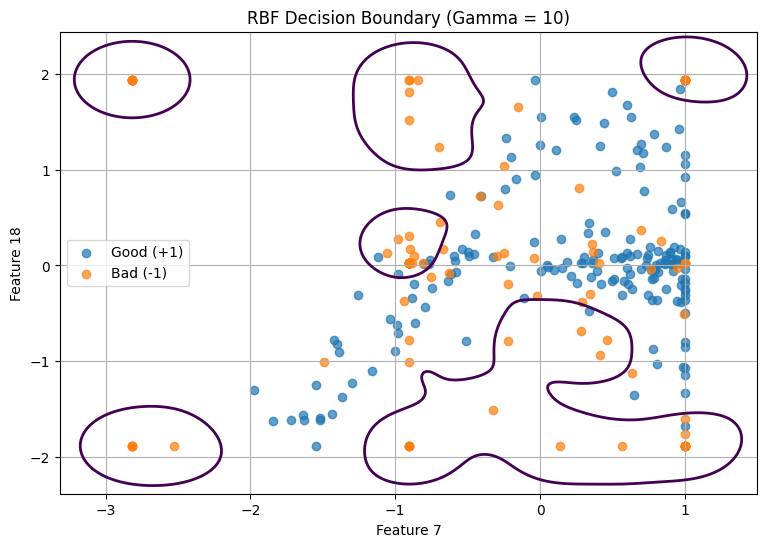

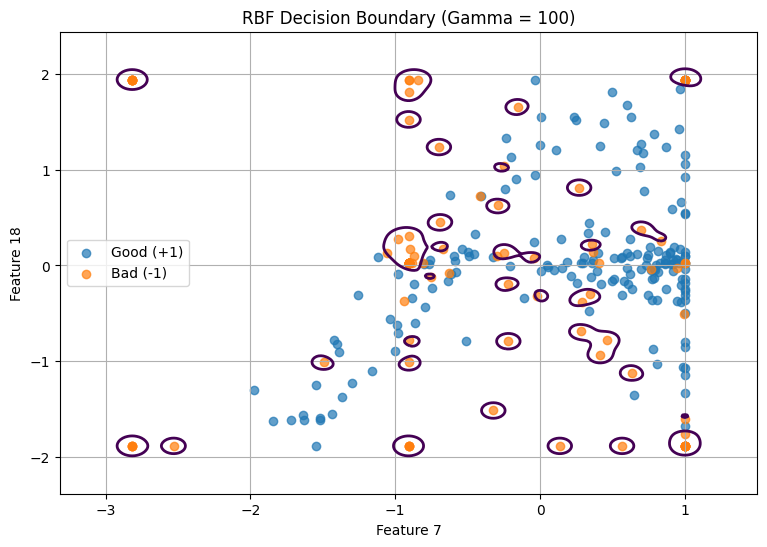

In [101]:
for gamma in gammas:
    kernel_function = lambda A, B, g=gamma: rbf_kernel(
        A,
        B,
        gamma=g
    )
    K_pair = kernel_function(
        X_pair,
        X_pair
    )
    alphas = svm_dual_qp_with_kernel(
        K_pair,
        y_pair,
        C=1.0
    )
    bias = compute_bias(
        K_pair,
        y_pair,
        alphas,
        C=1.0
    )
    plot_kernel_boundary(
        X_pair,
        y_pair,
        alphas,
        bias,
        kernel_function,
        selected_pair,
        f"RBF Decision Boundary (Gamma = {gamma})"
    )

In [102]:
rbf_support_results = []
for gamma in gammas:
    kernel_function = lambda A, B, g=gamma: rbf_kernel(
        A,
        B,
        gamma=g
    )
    K_pair = kernel_function(
        X_pair,
        X_pair
    )
    alphas = svm_dual_qp_with_kernel(
        K_pair,
        y_pair,
        C=1.0
    )
    support_vector_count = np.sum(
        alphas > 1e-5
    )
    rbf_support_results.append({
        "gamma": gamma,
        "support_vectors": support_vector_count
    })
for result in rbf_support_results:
    print(result)

{'gamma': 0.001, 'support_vectors': np.int64(280)}
{'gamma': 0.01, 'support_vectors': np.int64(203)}
{'gamma': 0.1, 'support_vectors': np.int64(184)}
{'gamma': 1, 'support_vectors': np.int64(164)}
{'gamma': 10, 'support_vectors': np.int64(195)}
{'gamma': 100, 'support_vectors': np.int64(250)}


The RBF kernel achieved its hightest crodd validation accuracy when gamma is 0.1, with accuracy of 95.36%. at the low gamma values the desicion bundary is smooth because each training point has a wider influece, as gamma increases the influence of the individual points becomes more localized producing more complex fragmented boundaries. at very high gamma the boundary form small regions round individual observations of same class basically overfitting. We can also see that the no of support vectors decreases from 280 at gamma 0.001 to 164 at gamma 1 but it increases again to 250 at gamma 100. this suggests that at extreme high values of gamma require more support vectors to represent the highly localized decision boundaries.

In [103]:
def fit_kernel_model(X, y, kernel_function, C=1.0):
    start_time = time.perf_counter()
    K = kernel_function(X, X)
    alphas = svm_dual_qp_with_kernel(
        K,
        y,
        C=C
    )
    bias = compute_bias(
        K,
        y,
        alphas,
        C=C
    )
    training_time = time.perf_counter() - start_time
    support_vectors = np.sum(
        alphas > 1e-5
    )
    return {
        "alphas": alphas,
        "bias": bias,
        "support_vectors": support_vectors,
        "training_time": training_time
    }

In [104]:
comparison_results = []

# Linear kernel
linear_kernel_function = lambda A, B: linear_kernel(A, B)
linear_model = fit_kernel_model(
    X_all,
    y_all,
    linear_kernel_function,
    C=1.0
)
linear_cv_accuracy = cross_validate_kernel(
    X_all,
    y_all,
    linear_kernel_function,
    C=1.0,
    n_splits=5,
    random_state=42
)[0]
comparison_results.append({
    "kernel": "Linear",
    "parameter": "-",
    "cv_accuracy": linear_cv_accuracy,
    "support_vectors": linear_model["support_vectors"],
    "training_time": linear_model["training_time"]
})


# Polynomial kernel, degree 3
poly_kernel_function = lambda A, B: polynomial_kernel(
    A,
    B,
    degree=3,
    gamma=1 / X_all.shape[1],
    coef0=1
)
poly_model = fit_kernel_model(
    X_all,
    y_all,
    poly_kernel_function,
    C=1.0
)
poly_cv_accuracy = cross_validate_kernel(
    X_all,
    y_all,
    poly_kernel_function,
    C=1.0,
    n_splits=5,
    random_state=42
)[0]
comparison_results.append({
    "kernel": "Polynomial",
    "parameter": "Degree 3",
    "cv_accuracy": poly_cv_accuracy,
    "support_vectors": poly_model["support_vectors"],
    "training_time": poly_model["training_time"]
})

# RBF kernel, gamma 0.1
rbf_kernel_function = lambda A, B: rbf_kernel(
    A,
    B,
    gamma=0.1
)
rbf_model = fit_kernel_model(
    X_all,
    y_all,
    rbf_kernel_function,
    C=1.0
)
rbf_cv_accuracy = cross_validate_kernel(
    X_all,
    y_all,
    rbf_kernel_function,
    C=1.0,
    n_splits=5,
    random_state=42
)[0]
comparison_results.append({
    "kernel": "RBF",
    "parameter": "Gamma 0.1",
    "cv_accuracy": rbf_cv_accuracy,
    "support_vectors": rbf_model["support_vectors"],
    "training_time": rbf_model["training_time"]
})

for result in comparison_results:
    print(result)

{'kernel': 'Linear', 'parameter': '-', 'cv_accuracy': np.float64(0.8821428571428573), 'support_vectors': np.int64(64), 'training_time': 0.07452117499997257}
{'kernel': 'Polynomial', 'parameter': 'Degree 3', 'cv_accuracy': np.float64(0.9285714285714286), 'support_vectors': np.int64(82), 'training_time': 0.06749452199983352}
{'kernel': 'RBF', 'parameter': 'Gamma 0.1', 'cv_accuracy': np.float64(0.9535714285714286), 'support_vectors': np.int64(157), 'training_time': 0.053314648001105525}


Based on the above cross-validation results, the RBF kernel with gamma 0.1 was selected because it achieved the highest validation accuracy of 95.36%. It outperformed the other kernels, which are the polynomial kernel with degree 3 and the linear kernel, achieving 92.86% and 88.21%, respectively. Since the Ionosphere dataset contains numerical radar signal features with nonlinear relationships, the RBF kernel was able to capture the nonlinear class structure more effectively. The RBF kernel used 157 support vectors, meaning its decision function relies on a larger number of training samples to model the nonlinear class structure. Although the support vector count is higher than that of the linear and polynomial kernels, the RBF kernel achieved better performance.

In [105]:
X_all = X_train_np
y_all = y_train_np
gamma = 0.1
rbf_kernel_function = lambda A, B: rbf_kernel(
    A,
    B,
    gamma=gamma
)

In [106]:
C_values = [1e-2, 1e-1, 1, 10, 100]
C_results = []
for C in C_values:
    cv_accuracy, fold_accuracies = cross_validate_kernel(
        X_all,
        y_all,
        rbf_kernel_function,
        C=C,
        n_splits=5,
        random_state=42
    )
    model = fit_kernel_model(
        X_all,
        y_all,
        rbf_kernel_function,
        C=C
    )
    alphas = model["alphas"]
    bias = model["bias"]
    train_predictions = svm_predict_kernel(
        X_all,
        y_all,
        X_all,
        alphas,
        bias,
        rbf_kernel_function
    )
    training_accuracy = np.mean(
        train_predictions == y_all
    )
    training_error = 1 - training_accuracy
    cv_error = 1 - cv_accuracy
    C_results.append({
        "C": C,
        "training_error": training_error,
        "cv_error": cv_error,
        "cv_accuracy": cv_accuracy,
        "support_vectors": model["support_vectors"],
        "training_time": model["training_time"]
    })

for result in C_results:
    print(result)

{'C': 0.01, 'training_error': np.float64(0.36071428571428577), 'cv_error': np.float64(0.36071428571428565), 'cv_accuracy': np.float64(0.6392857142857143), 'support_vectors': np.int64(205), 'training_time': 0.07793650600069668}
{'C': 0.1, 'training_error': np.float64(0.06428571428571428), 'cv_error': np.float64(0.33571428571428563), 'cv_accuracy': np.float64(0.6642857142857144), 'support_vectors': np.int64(208), 'training_time': 0.06103950800024904}
{'C': 1, 'training_error': np.float64(0.014285714285714235), 'cv_error': np.float64(0.046428571428571375), 'cv_accuracy': np.float64(0.9535714285714286), 'support_vectors': np.int64(157), 'training_time': 0.05766209099965636}
{'C': 10, 'training_error': np.float64(0.0035714285714285587), 'cv_error': np.float64(0.05714285714285716), 'cv_accuracy': np.float64(0.9428571428571428), 'support_vectors': np.int64(153), 'training_time': 0.06408337599896186}
{'C': 100, 'training_error': np.float64(0.0), 'cv_error': np.float64(0.05714285714285716), 'cv

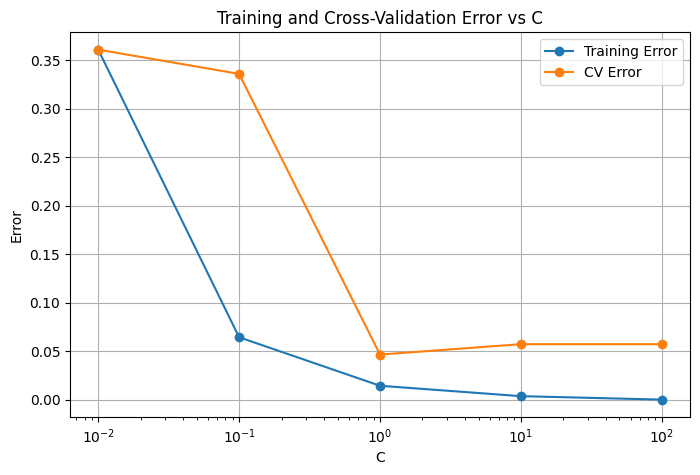

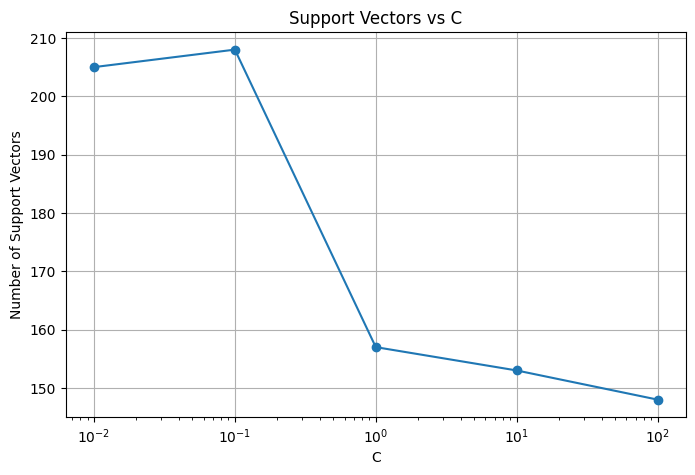

In [107]:
C_values_plot = [
    result["C"] for result in C_results
]
training_errors = [
    result["training_error"] for result in C_results
]
cv_errors = [
    result["cv_error"] for result in C_results
]
support_vectors = [
    result["support_vectors"] for result in C_results
]
plt.figure(figsize=(8, 5))
plt.semilogx(
    C_values_plot,
    training_errors,
    marker="o",
    label="Training Error"
)
plt.semilogx(
    C_values_plot,
    cv_errors,
    marker="o",
    label="CV Error"
)
plt.xlabel("C")
plt.ylabel("Error")
plt.title("Training and Cross-Validation Error vs C")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogx(
    C_values_plot,
    support_vectors,
    marker="o"
)
plt.xlabel("C")
plt.ylabel("Number of Support Vectors")
plt.title("Support Vectors vs C")
plt.grid(True)
plt.show()

In [108]:
best_C_result = min(
    C_results,
    key=lambda result: (result["cv_error"], result["C"])
)
smallest_C_result = C_results[0]
improvement = (
    smallest_C_result["cv_error"]
    - best_C_result["cv_error"]
)
print("Best C:", best_C_result["C"])
print("Best CV error:", best_C_result["cv_error"])
print("Smallest C error:", smallest_C_result["cv_error"])
print("Error improvement:", improvement)

Best C: 1
Best CV error: 0.046428571428571375
Smallest C error: 0.36071428571428565
Error improvement: 0.3142857142857143


The parameter C controls the penalty assigned to misclassified training points and points the violate the margin. a small c allows more margin vialations and provides stronger relurization while large c penalizzes violations more heavily. as c increases the model attempts to classify more training points correctly which can reduce training error but may increase overfitting. the crodd validation error may initially decrease and then increase as the model becomes too complex. the number of support vectors can decrease as c increases because fewer points are allowed to violate the margin, but this greatly depends on the dataset and the kernel being used.

In [110]:
def classification_metrics(y_true, y_pred, positive_class=1):
    tp = np.sum(
        (y_true == positive_class) &
        (y_pred == positive_class)
    )
    tn = np.sum(
        (y_true != positive_class) &
        (y_pred != positive_class)
    )
    fp = np.sum(
        (y_true != positive_class) &
        (y_pred == positive_class)
    )
    fn = np.sum(
        (y_true == positive_class) &
        (y_pred != positive_class)
    )
    accuracy = (tp + tn) / len(y_true)
    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )
    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [111]:
C_values = [1e-2, 1e-1, 1, 10, 100]

def tune_C(
    X,
    y,
    kernel_function,
    C_values,
    n_splits=5,
    random_state=42
):
    results = []
    for C in C_values:
        cv_accuracy, fold_accuracies = cross_validate_kernel(
            X,
            y,
            kernel_function,
            C=C,
            n_splits=n_splits,
            random_state=random_state
        )
        results.append({
            "C": C,
            "cv_accuracy": cv_accuracy,
            "cv_error": 1 - cv_accuracy
        })
    best_result = min(
        results,
        key=lambda result: (result["cv_error"], result["C"])
    )

    return best_result, results

In [112]:
linear_kernel_function = lambda A, B: linear_kernel(A, B)
best_linear_C, linear_C_results = tune_C(
    X_all,
    y_all,
    linear_kernel_function,
    C_values
)
print("Best linear C:", best_linear_C)

Best linear C: {'C': 0.1, 'cv_accuracy': np.float64(0.8857142857142858), 'cv_error': np.float64(0.11428571428571421)}


In [113]:
poly_kernel_function = lambda A, B: polynomial_kernel(
    A,
    B,
    degree=3,
    gamma=1 / X_all.shape[1],
    coef0=1
)
best_poly_C, poly_C_results = tune_C(
    X_all,
    y_all,
    poly_kernel_function,
    C_values
)
print("Best polynomial C:", best_poly_C)

Best polynomial C: {'C': 1, 'cv_accuracy': np.float64(0.9285714285714286), 'cv_error': np.float64(0.0714285714285714)}


In [114]:
rbf_kernel_function = lambda A, B: rbf_kernel(
    A,
    B,
    gamma=0.1
)
best_rbf_C, rbf_C_results = tune_C(
    X_all,
    y_all,
    rbf_kernel_function,
    C_values
)
print("Best RBF C:", best_rbf_C)

Best RBF C: {'C': 1, 'cv_accuracy': np.float64(0.9535714285714286), 'cv_error': np.float64(0.046428571428571375)}


In [115]:
linear_model = fit_kernel_model(
    X_all,
    y_all,
    linear_kernel_function,
    C=best_linear_C["C"]
)
poly_model = fit_kernel_model(
    X_all,
    y_all,
    poly_kernel_function,
    C=best_poly_C["C"]
)
rbf_model = fit_kernel_model(
    X_all,
    y_all,
    rbf_kernel_function,
    C=best_rbf_C["C"]
)

In [116]:
def predict_with_model(
    model,
    X_train,
    y_train,
    X_test,
    kernel_function
):
    return svm_predict_kernel(
        X_train,
        y_train,
        X_test,
        model["alphas"],
        model["bias"],
        kernel_function
    )

In [118]:
linear_test_pred = predict_with_model(
    linear_model,
    X_all,
    y_all,
    X_test_standardized,
    linear_kernel_function
)
poly_test_pred = predict_with_model(
    poly_model,
    X_all,
    y_all,
    X_test_standardized,
    poly_kernel_function
)
rbf_test_pred = predict_with_model(
    rbf_model,
    X_all,
    y_all,
    X_test_standardized,
    rbf_kernel_function
)

In [120]:
majority_class = (
    1 if np.sum(y_all == 1) >= np.sum(y_all == -1)
    else -1
)
majority_test_pred = np.full(
    len(y_test),
    majority_class
)

In [122]:
evaluation_results = []
models = [
    ("Linear", linear_test_pred),
    ("Polynomial", poly_test_pred),
    ("RBF", rbf_test_pred),
    ("Majority Baseline", majority_test_pred)
]
for model_name, predictions in models:
    metrics = classification_metrics(
        y_test,
        predictions,
        positive_class=1
    )
    evaluation_results.append({
        "model": model_name,
        **metrics
    })
for result in evaluation_results:
    print(result)

{'model': 'Linear', 'accuracy': np.float64(0.8309859154929577), 'precision': np.float64(0.8148148148148148), 'recall': np.float64(0.9565217391304348), 'f1': np.float64(0.8800000000000001)}
{'model': 'Polynomial', 'accuracy': np.float64(0.8591549295774648), 'precision': np.float64(0.8461538461538461), 'recall': np.float64(0.9565217391304348), 'f1': np.float64(0.8979591836734695)}
{'model': 'RBF', 'accuracy': np.float64(0.9577464788732394), 'precision': np.float64(0.9574468085106383), 'recall': np.float64(0.9782608695652174), 'f1': np.float64(0.967741935483871)}
{'model': 'Majority Baseline', 'accuracy': np.float64(0.647887323943662), 'precision': np.float64(0.647887323943662), 'recall': np.float64(1.0), 'f1': np.float64(0.7863247863247863)}


The RBF kernel achieved the highest performance on the untouched test set, with an accuracy of 95.77% and an F1-score of 96.77%. The polynomial kernel achieved an accuracy of 85.92%, while the linear kernel achieved 83.10%.

The RBF kernel performed better because it can capture nonlinear relationships between the radar signal features. It also achieved higher precision and recall compared to the other SVM models. The majority baseline achieved an accuracy of 64.79%, which is lower than all three SVM models.

Although the majority baseline achieved 100% recall, it predicted only the majority class. Therefore, its precision and F1-score do not indicate balanced classification performance.

In [124]:
def compute_hinge_losses(X_train, y_train, alphas, bias, kernel_function):
    K = kernel_function(X_train, X_train)
    decision_values = K @ (alphas * y_train) + bias
    hinge_losses = np.maximum(
        0,
        1 - y_train * decision_values
    )
    return hinge_losses, decision_values

rbf_hinge_losses, rbf_decision_values = compute_hinge_losses(
    X_all,
    y_all,
    rbf_model["alphas"],
    rbf_model["bias"],
    rbf_kernel_function
)

linear_hinge_losses, linear_decision_values = compute_hinge_losses(
    X_all,
    y_all,
    linear_model["alphas"],
    linear_model["bias"],
    linear_kernel_function
)

rbf_sv_count = np.sum(rbf_model["alphas"] > 1e-5)
linear_sv_count = np.sum(linear_model["alphas"] > 1e-5)
print("RBF support vector fraction:",
      rbf_sv_count / len(y_all))
print("Linear support vector fraction:",
      linear_sv_count / len(y_all))

print("RBF nonzero hinge losses:",
      np.sum(rbf_hinge_losses > 1e-3))

print("Linear nonzero hinge losses:",
      np.sum(linear_hinge_losses > 1e-3))

RBF support vector fraction: 0.5607142857142857
Linear support vector fraction: 0.32142857142857145
RBF nonzero hinge losses: 33
Linear nonzero hinge losses: 67


In [125]:
top_indices = np.argsort(linear_hinge_losses)[-10:][::-1]
for idx in top_indices:
    print(
        "Index:", idx,
        "Label:", y_all[idx],
        "Hinge Loss:", linear_hinge_losses[idx],
        "Features:", X_all[idx]
    )

Index: 242 Label: -1 Hinge Loss: 2.4369637814246228 Features: [ 0.33333333 -0.1037194   0.75624265  0.45063814  1.41110895  0.44936826
  1.04984003  0.69498733 -0.60106387  0.90333272 -0.18115815  0.91996578
 -1.94976793  0.92679416  1.76840469  0.97604817 -0.08986954  0.85259038
  0.37575211  1.10569722 -1.32232337  0.86231056 -1.47466876 -0.12863571
 -0.42531077  0.9008472   0.44507145  0.43071565  0.85982884  0.93299163
  1.52506957  0.91093395  1.37869069]
Index: 218 Label: -1 Hinge Loss: 2.4020059588545988 Features: [ 0.33333333  0.16012945 -0.28705881  0.5722255  -0.23590083  0.94060166
  1.08861346  0.35824299 -0.50062957  0.06732412 -0.66774963  0.7012135
 -0.03564512  0.4114809   2.02431992  0.27673206  0.44875444  0.51831694
  0.22004402  1.12997634 -0.5646697   1.05811188 -1.74517573  0.35115354
  0.79089221  0.05925822  0.40233075  0.07456615  0.20341538  0.2672561
  0.26165603  1.25717348  2.04290357]
Index: 57 Label: -1 Hinge Loss: 2.3594097828495735 Features: [ 0.3333333

My best model RBF kernel has 56.07% of the training samples as support vectors. This indicates that the RBF model requires a relatively large no of support vectors but this is expected as the model captures more complex relationships in the data.


My RBF has 33 non zero hinge loss points and the linear SVM has 67. the RBF model has fewer points than linear svm. this indicates the fewer training points violed the margin under RBF model than under linear svm meaning a better fit to the training data.


above outset cell contains the traiknign points and their hinge losses from this we can see that point index 242 has the largest hinge loss 2.437.


A clear pattern is that all the top ten points with the largest hinge loss belong to class -1. this suggest that the linear SVM has more difficukty correctly classifiying sammples from -1 class with good margin. But we cant infer anything form the individual feature values because the features are standardized and their original rader feature meanings are ot available.


As we see that the model perfered bad for classifying a particular class , we can implement a class weighted SVM training giving higher penalty to errors on this particular class (-1). This could help the model focus more on correctly classifying the difficult -1 samples. but this could potentially reduce the performance on the other classes.